# DHRP: Differentiable Hierarchical Risk Parity

**Full Experimental Pipeline (Colab GPU)**

This notebook reproduces every numerical result reported in the DHRP paper. The pipeline:
1. Loads 14 years of daily price data for three balanced 10-asset ETF universes (developed markets, emerging markets, commodities) and Fama-French factors.
2. Trains the DHRP layer end-to-end on the in-sample period (2012-04 through 2020-06) with multi-objective loss (CRRA + Sharpe + curriculum HRP regularization).
3. Backtests DHRP and a full benchmark set (EW, MV, MINVAR, MAXDIV, HRP, RP, MLP, Transformer, PPO) on the held-out OOS period (2020-07 through 2026-04).
4. Reports a layered statistical battery: HAC-robust Sharpe t-stats, Fama-French six-factor alphas, Jobson-Korkie/Memmel parametric Sharpe tests, stationary block bootstrap with Holm-Bonferroni correction, Diebold-Mariano forecast accuracy, SPA, and Model Confidence Set.
5. Adds ablations (tree depth, loss components, hierarchical inductive bias), multi-seed robustness, transaction-cost sensitivity, and regime-conditional analysis.

**LLM-DHRP** (a multimodal extension fusing global FinBERT summaries via gated cross-attention) is trained and backtested under the same protocol but reported only as a *brief negative ablation*: it does not improve over the base DHRP layer and is mentioned in the paper purely so practitioners do not assume the opposite. The headline contribution is DHRP.

Run all cells in order. Upload your `HRP_AI` folder to Google Drive first, then cell 1 mounts Drive and sets up the environment.


In [1]:
# === CELL 1: SETUP ===
import os, sys, subprocess, glob, shutil, configparser
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    try:
        drive.mount("/content/drive")
    except ValueError:
        pass  # already mounted

    # Always use a fresh /content/HRP_AI clone.
    # Drive copies are unreliable: git reset --hard does not reliably
    # update files through the Drive FUSE mount, and old nested
    # src/<pkg>/__init__.py files survive resets and shadow the flat
    # src/*.py modules. Drive is read-only here, used only for .env and
    # cached results.
    REPO_PATH = "/content/HRP_AI"
    # Repository URL resolution, in order of priority:
    #   1. DHRP_REPO_URL env var (set in this notebook session)
    #   2. /content/drive/MyDrive/HRP_AI/.dhrp_repo_url  (one-time setup)
    #   3. Drive-mounted checkout Git remote (VS Code Colab extension)
    #   4. anonymized placeholder (only useful for the review supplementary)
    def _clean_repo_url(repo_url):
        repo_url = (repo_url or "").strip()
        if repo_url.startswith("git@github.com:"):
            repo_url = "https://github.com/" + repo_url.split(":", 1)[1]
        return repo_url

    def _repo_url_from_git_config(repo_dir):
        repo_dir = os.path.abspath(repo_dir)
        while True:
            cfg_path = os.path.join(repo_dir, ".git", "config")
            if os.path.exists(cfg_path):
                parser = configparser.RawConfigParser()
                parser.read(cfg_path)
                section = 'remote "origin"'
                if parser.has_option(section, "url"):
                    return _clean_repo_url(parser.get(section, "url"))
            parent = os.path.dirname(repo_dir)
            if parent == repo_dir:
                return None
            repo_dir = parent

    REPO_URL = _clean_repo_url(os.environ.get("DHRP_REPO_URL"))
    if not REPO_URL or "<your-fork>" in REPO_URL:
        for cfg in ("/content/drive/MyDrive/HRP_AI/.dhrp_repo_url",
                    "/content/drive/My Drive/HRP_AI/.dhrp_repo_url",
                    "/content/drive/MyDrive/.dhrp_repo_url"):
            if os.path.exists(cfg):
                REPO_URL = _clean_repo_url(open(cfg).read())
                if REPO_URL:
                    break
    if not REPO_URL or "<your-fork>" in REPO_URL:
        for repo_dir in (REPO_PATH,
                         "/content/drive/MyDrive/HRP_AI",
                         "/content/drive/My Drive/HRP_AI",
                         os.getcwd()):
            REPO_URL = _repo_url_from_git_config(repo_dir)
            if REPO_URL and "<your-fork>" not in REPO_URL:
                print(f"Using repository URL from {repo_dir}/.git/config")
                break
    if not REPO_URL or "<your-fork>" in REPO_URL:
        raise RuntimeError(
            "DHRP_REPO_URL is not set and no Drive-mounted git remote was found. "
            "Either run in a cell BEFORE this one: "
            "os.environ['DHRP_REPO_URL'] = 'https://github.com/<your-account>/dhrp-allocation.git', "
            "or save the URL once with: "
            "echo 'https://github.com/<your-account>/dhrp-allocation.git' "
            "> /content/drive/MyDrive/HRP_AI/.dhrp_repo_url"
        )
    if os.path.isdir(REPO_PATH):
        print("Refreshing /content/HRP_AI...")
        subprocess.call(["git", "-C", REPO_PATH, "fetch", "--all"],
                        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        subprocess.call(["git", "-C", REPO_PATH, "reset", "--hard", "origin/main"],
                        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        subprocess.call(["git", "-C", REPO_PATH, "clean", "-fdx",
                         "-e", ".env", "-e", "results/", "-e", "data/cache/"],
                        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    else:
        print(f"Cloning {REPO_URL} -> {REPO_PATH}...")
        subprocess.check_call(["git", "clone", REPO_URL, REPO_PATH])

    os.chdir(REPO_PATH)
    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)

    # Defensive: remove any stale nested src/<pkg>/ directories that could
    # shadow the flat src/*.py modules, and flush any half-imported `src`.
    for stale in ("data", "models", "training", "evaluation", "visualization"):
        stale_dir = os.path.join(REPO_PATH, "src", stale)
        if os.path.isdir(stale_dir):
            shutil.rmtree(stale_dir, ignore_errors=True)
    stale_init = os.path.join(REPO_PATH, "src", "__init__.py")
    if os.path.isfile(stale_init):
        try: os.remove(stale_init)
        except OSError: pass
    for _modname in [m for m in list(sys.modules) if m == "src" or m.startswith("src.")]:
        del sys.modules[_modname]

    # Copy .env from Drive if available (Drive is read-only credential store)
    env_candidates = [
        "/content/drive/MyDrive/HRP_AI/.env",
        "/content/drive/MyDrive/.env",
        "/content/drive/My Drive/HRP_AI/.env",
    ]
    if not os.path.exists(".env"):
        for ep in env_candidates:
            if os.path.exists(ep):
                shutil.copy(ep, ".env")
                print(f"Copied .env from {ep}")
                break
    print(f"Working dir: {os.getcwd()}")

    !pip install -q torch transformers tokenizers huggingface-hub         requests pandas-datareader fredapi cvxpy seaborn python-dotenv         scipy statsmodels bitsandbytes accelerate feedparser datasets yfinance         sentence-transformers scikit-learn         gs-quant
else:
    parent = os.path.abspath("..")
    if parent not in sys.path:
        sys.path.insert(0, parent)

import warnings
warnings.filterwarnings("ignore")

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
EMBEDDING_MODEL = os.environ.get("DHRP_EMBEDDING_MODEL", "finlang").strip().lower()
if EMBEDDING_MODEL not in {"finlang", "finbert"}:
    raise ValueError("DHRP_EMBEDDING_MODEL must be 'finlang' or 'finbert'")
TRAIN_END = os.environ.get("DHRP_TRAIN_END", "2020-06-30")
OOS_START = os.environ.get("DHRP_OOS_START", "2020-07-01")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Train/OOS split: train <= {TRAIN_END}, OOS >= {OOS_START}")

# --- Clean stale results from previous runs ---
def clean_stale_results():
    patterns = [
        "results/*.csv", "results/*.png",
        "results/models/*.pt",
        "results/features/*.npz", "results/features/*.csv",
        "results/full/*.csv",
        "results/figures/*.png",
    ]
    total = 0
    for pat in patterns:
        for f in glob.glob(pat):
            os.remove(f)
            total += 1
    if total:
        print(f"Cleaned {total} stale result files.")

clean_stale_results()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using repository URL from /content/HRP_AI/.git/config
Refreshing /content/HRP_AI...
Working dir: /content/HRP_AI
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB
Embedding model: finlang
Train/OOS split: train <= 2020-06-30, OOS >= 2020-07-01


In [2]:
# === CELL 2: LOAD PRICE + VOLUME DATA (all 3 universes) ===
# Defensive self-heal: if Drive still has the old nested package layout
# (src/data/__init__.py etc.) it shadows the flat src/data.py and the
# imports below fail with 'cannot import name load_etf_volume_data'.
import os, sys, shutil
_repo = globals().get('REPO_PATH') or os.getcwd()
_stale_dirs = [os.path.join(_repo, 'src', s)
               for s in ('data', 'models', 'training', 'evaluation', 'visualization')]
if any(os.path.isdir(d) for d in _stale_dirs):
    for d in _stale_dirs:
        if os.path.isdir(d):
            shutil.rmtree(d, ignore_errors=True)
    _stale_init = os.path.join(_repo, 'src', '__init__.py')
    if os.path.isfile(_stale_init):
        try: os.remove(_stale_init)
        except OSError: pass
    for _modname in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
        del sys.modules[_modname]
    print('Cleared stale nested src/ packages; using flat src/*.py modules.')

from datetime import datetime, timedelta
from src.data import load_universe, load_fama_french, load_etf_volume_data, UNIVERSES

END = datetime.now().strftime('%Y-%m-%d')
START = (datetime.now() - timedelta(days=14*365)).strftime('%Y-%m-%d')  # 14yrs (INDA Feb 2012 limit)
print(f'Period: {START} to {END}\n')

print(f'=== DM Universe ({len(UNIVERSES["DM"])} ETFs) ===')
DM_prices = load_universe('DM', START, END)

print(f'\n=== EM Universe ({len(UNIVERSES["EM"])} ETFs) ===')
EM_prices = load_universe('EM', START, END)

print(f'\n=== Commodities Universe ({len(UNIVERSES["Commodities"])} ETFs) ===')
CMD_prices = load_universe('Commodities', START, END)

print('\n=== Fama-French Factors ===')
FF = load_fama_french(START, END)

# Load volume data for enhanced features
print('\n=== Volume Data ===')
try:
    DM_vol = load_etf_volume_data(list(UNIVERSES['DM'].values()), START, END)
    EM_vol = load_etf_volume_data(list(UNIVERSES['EM'].values()), START, END)
    CMD_vol = load_etf_volume_data(list(UNIVERSES['Commodities'].values()), START, END)
    print(f'DM volume: {DM_vol.shape}, EM volume: {EM_vol.shape}, CMD volume: {CMD_vol.shape}')
except Exception as e:
    print(f'Volume data unavailable ({e}), proceeding without')
    DM_vol = EM_vol = CMD_vol = None

Period: 2012-05-16 to 2026-05-13

=== DM Universe (10 ETFs) ===
  [cache] SPY: 3517 days
  [cache] QQQ: 3517 days
  [cache] IWM: 3517 days
  [cache] EFA: 3517 days
  [cache] VGK: 3517 days
  [cache] TLT: 3517 days
  [cache] IEF: 3517 days
  [cache] LQD: 3517 days
  [cache] VNQ: 3517 days
  [cache] UUP: 3517 days
  Total: 3517x10 assets, coverage: 100.0%

=== EM Universe (10 ETFs) ===
  [cache] EEM: 3517 days
  [cache] EWZ: 3517 days
  [cache] FXI: 3517 days
  [cache] EWY: 3517 days
  [cache] EWT: 3517 days
  [cache] INDA: 3517 days
  [cache] EWW: 3517 days
  [cache] EZA: 3517 days
  [cache] THD: 3517 days
  [cache] TUR: 3517 days
  Total: 3517x10 assets, coverage: 100.0%

=== Commodities Universe (10 ETFs) ===
  [cache] USO: 3517 days
  [cache] UNG: 3517 days
  [cache] GLD: 3517 days
  [cache] SLV: 3517 days
  [cache] DBA: 3517 days
  [cache] DBC: 3517 days
  [cache] CPER: 3517 days
  [cache] WEAT: 3517 days
  [cache] CORN: 3517 days
  [cache] SOYB: 3517 days
  Total: 3517x10 assets, c

In [3]:
# === CELL 3: LOAD HEADLINES (all sources including GDELT) ===
from src.data import load_all_headlines
import pandas as pd

# Collect headlines from ALL available sources
# GDELT provides 10-year historical coverage (2016-2026)
# yfinance/RSS provide recent headlines
# PhraseBank/FiQA provide static financial NLP training data
all_tickers = (
    list(UNIVERSES['DM'].values()) +
    list(UNIVERSES['EM'].values()) +
    list(UNIVERSES['Commodities'].values())
)
all_tickers = list(set(all_tickers))

print(f'Fetching headlines for {len(all_tickers)} tickers from all sources...')
headlines_df = load_all_headlines(
    all_tickers, START, END,
    max_headlines=100,
    use_rss=True,
    use_phrasebank=True,
    use_fiqa=True,
    use_gdelt=True,           # GDELT historical headlines (primary source)
    gdelt_max_per_ticker=250,  # 250 per ticker per chunk
    gdelt_chunk_months=12,     # 12-month windows (~15 min vs 100 min)
)
print(f'\nTotal headlines: {len(headlines_df)}')
if not headlines_df.empty:
    print(f'Date range: {headlines_df["date"].min()} to {headlines_df["date"].max()}')
    print(f'Tickers with news: {headlines_df["ticker"].nunique()}')
    print(f'Sources: {headlines_df["source"].value_counts().head(10).to_dict()}')
    # Show coverage by year
    headlines_df['year'] = pd.to_datetime(headlines_df['date']).dt.year
    print(f'Headlines by year:\n{headlines_df["year"].value_counts().sort_index().to_string()}')
    headlines_df = headlines_df.drop(columns=['year'])

Fetching headlines for 30 tickers from all sources...
  Loading GDELT historical headlines...
  GDELT: 27/31 tickers cached (31924 headlines)
  Fetching 4 tickers (14 chunks each, 4 parallel workers, ETA ~0 min)...
    [28/31] EFA: 0 headlines | 3 left (~17.3m)
    [29/31] EWT: 0 headlines | 2 left (~6.2m)
    [30/31] VNQ: 0 headlines | 1 left (~2.4m)
    [31/31] USO: 0 headlines | 0 left (~0s)
  GDELT total: 29036 unique headlines (436s elapsed)
    GDELT: 29036 headlines
  Loading yfinance headlines...
    yfinance: 256 headlines
  Loading RSS headlines...
    RSS: 91 headlines
  Loading Financial PhraseBank...
Financial PhraseBank unavailable: Dataset scripts are no longer supported, but found financial_phrasebank.py
  Loading FiQA dataset...


    FiQA: 1213 sentences
  Total unique headlines: 30439

Total headlines: 30439
Date range: 2018-04-14 00:00:00 to 2026-05-13 11:15:03.990259
Tickers with news: 31
Sources: {'FiQA': 1111, 'GDELT:marketscreener.com': 665, 'GDELT:finance.yahoo.com': 631, 'GDELT:seekingalpha.com': 491, 'GDELT:finanznachrichten.de': 359, 'GDELT:dailypolitical.com': 336, 'GDELT:hellenicshippingnews.com': 333, 'GDELT:fool.com': 332, 'GDELT:msn.com': 319, 'GDELT:prnewswire.com': 317}
Headlines by year:
year
2018    3082
2019    3460
2020    2954
2021    2893
2022    2998
2023    3143
2024    3546
2025    3556
2026    4807


In [4]:
# === CELL 4: TEXT EMBEDDINGS (FinBERT or FinLang sentence-transformer) ===
# Dispatched by EMBEDDING_MODEL flag in Cell 1.
# FinLang is recommended: avoids BERT anisotropy by design (sentence-transformer trained
# with contrastive loss on financial text from Investopedia).
import os
import numpy as np
import torch

if "device" not in globals():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Cell 4 fallback device: {device}")
if "EMBEDDING_MODEL" not in globals():
    EMBEDDING_MODEL = os.environ.get("DHRP_EMBEDDING_MODEL", "finlang").strip().lower()
    print(f"Cell 4 fallback embedding model: {EMBEDDING_MODEL}")
if EMBEDDING_MODEL not in {"finlang", "finbert"}:
    raise ValueError("DHRP_EMBEDDING_MODEL must be 'finlang' or 'finbert'")

headline_to_emb = {}
if not headlines_df.empty:
    unique_headlines = headlines_df['headline'].unique().tolist()
    print(f'Extracting {EMBEDDING_MODEL} embeddings for {len(unique_headlines)} unique headlines...')

    if EMBEDDING_MODEL == 'finlang':
        from src.data import get_finance_sentence_embeddings
        embs = get_finance_sentence_embeddings(unique_headlines, device=device)
    else:
        from src.data import get_finbert_embeddings
        embs = get_finbert_embeddings(unique_headlines, batch_size=64, device=device)

    print(f'Embeddings shape: {embs.shape}')

    # Per-headline anisotropy diagnostic — distinguishes BERT-layer collapse from per-asset uniformity
    if embs.shape[0] >= 50:
        from numpy.linalg import norm
        sample = embs[:200] if len(embs) > 200 else embs
        norms = norm(sample, axis=-1)
        good = norms > 1e-6
        if good.sum() > 1:
            X = sample[good] / norms[good][:, None]  # L2 normalize
            sims_all = X @ X.T
            iu = np.triu_indices_from(sims_all, k=1)
            sims = sims_all[iu]
            print(f'  Per-headline cosine similarity (sampled): mean={sims.mean():.3f}, std={sims.std():.3f}')
            print(f'  Range: [{sims.min():.3f}, {sims.max():.3f}]')
            if sims.std() > 0.10:
                print('  [GOOD] Embeddings show per-headline variance — model layer is fine.')
                print('         If aggregated text is still anisotropic, root cause is per-asset uniformity.')
            elif sims.std() > 0.03:
                print('  [MODERATE] Some per-headline variance but still concentrated.')
            else:
                print('  [BAD] Embeddings nearly identical at the per-headline level — try a different model.')

    headline_to_emb = {h: embs[i] for i, h in enumerate(unique_headlines)}
    print(f'VRAM after extraction: {torch.cuda.memory_allocated()/1e9:.2f} GB' if torch.cuda.is_available() else 'CPU mode')
else:
    print('No headlines available. Proceeding with price-only features.')

Extracting finlang embeddings for 30439 unique headlines...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embeddings shape: (30439, 768)
  Per-headline cosine similarity (sampled): mean=0.270, std=0.149
  Range: [-0.201, 0.999]
  [GOOD] Embeddings show per-headline variance — model layer is fine.
         If aggregated text is still anisotropic, root cause is per-asset uniformity.
VRAM after extraction: 0.45 GB


In [5]:
# === CELL 5: GEMINI 3.1 STRUCTURED SENTIMENT (API call, zero GPU) ===
from src.data import extract_sentiment_batch, GEMINI_FEATURE_DIM
import os

# Use Gemini 3.1 Pro for 6-dimensional structured sentiment:
# [sentiment_score, risk_level, regime, confidence, sector_impact, rate_sensitivity]
# Schema-enforced JSON output - no parsing errors, no GPU compute.

# API key from .env or Colab secrets
api_key = os.environ.get('GOOGLE_API_KEY')
if not api_key:
    try:
        from google.colab import userdata
        api_key = userdata.get('GEMINI_API_KEY')
    except Exception:
        pass
if not api_key:
    from dotenv import load_dotenv
    load_dotenv()
    api_key = os.environ.get('GOOGLE_API_KEY')

sentiment_by_ticker = {}
if api_key and not headlines_df.empty:
    print('=== GEMINI 3.1 PRO STRUCTURED SENTIMENT ===')
    print('  Model: gemini-3.1-pro-preview')
    print(f'  Output: {GEMINI_FEATURE_DIM}-dim structured JSON per headline')
    print('  Compute: API calls (zero GPU)')
    print()
    sentiment_by_ticker = extract_sentiment_batch(
        headlines_df,
        api_key=api_key,
        model='gemini-3.1-pro-preview',
        max_headlines_per_ticker=15,
        batch_size=10,
        delay_between_calls=0.5,
    )
    n_sent = len(sentiment_by_ticker)
    print(f'  Sentiment extracted for {n_sent} tickers')
    print(f'  Feature dim: {GEMINI_FEATURE_DIM} per ticker')
else:
    if not api_key:
        print('No GOOGLE_API_KEY found. Set it in .env or Colab secrets.')
        print('Get a free key at https://aistudio.google.com/')
    else:
        print('No headlines available for sentiment extraction.')


=== GEMINI 3.1 PRO STRUCTURED SENTIMENT ===
  Model: gemini-3.1-pro-preview
  Output: 6-dim structured JSON per headline
  Compute: API calls (zero GPU)

  Loaded 31 cached ticker sentiments from results/features/gemini_sentiment.json
  Cached 31 tickers to results/features/gemini_sentiment.json
  API calls: 0, cached: 31
  Sentiment extracted for 31 tickers
  Feature dim: 6 per ticker


In [6]:
# === CELL 6: BUILD TEMPORAL TEXT FEATURE TENSORS (PIT, no look-ahead) ===
# TIME-VARYING text features: each sample date uses only headlines from its
# lookback window (default 60 days). Replaces the previous bug where
# np.tile(prior_embs, (n_samp, 1, 1)) produced identical features at every
# timestep — which collapsed per-timestep cosine similarity to 1.0 regardless
# of embedding model quality.
from src.data import build_dataset, DEFAULT_FDIM
from src.data import build_temporal_text_tensor
from src.data import build_gemini_text_tensor, GEMINI_FEATURE_DIM
import os
import pandas as pd
import numpy as np

if "TRAIN_END" not in globals():
    TRAIN_END = os.environ.get("DHRP_TRAIN_END", "2020-06-30")
    print(f"Cell 6 fallback TRAIN_END: {TRAIN_END}")
if "OOS_START" not in globals():
    OOS_START = os.environ.get("DHRP_OOS_START", "2020-07-01")
    print(f"Cell 6 fallback OOS_START: {OOS_START}")
if "headline_to_emb" not in globals():
    headline_to_emb = {}
    print("Cell 6 fallback: no headline embeddings found")
if "sentiment_by_ticker" not in globals():
    sentiment_by_ticker = {}
    print("Cell 6 fallback: no Gemini sentiment features found")

TEXT_LOOKBACK_DAYS = 90   # rolling window for per-asset text aggregation
TEXT_MIN_HEADLINES = 2    # minimum headlines in window before falling back

print('=== Building TEMPORAL text feature tensors ===')
text_dm = text_em = text_cmd = None
text_dm_pit = text_em_pit = text_cmd_pit = None

if headline_to_emb:
    for label, prices, universe_key, vol_data in [
        ('DM', DM_prices, 'DM', DM_vol),
        ('EM', EM_prices, 'EM', EM_vol),
        ('CMD', CMD_prices, 'Commodities', CMD_vol),
    ]:
        # Get sample dates aligned with build_dataset's X tensor
        X, S, R, H, sample_dates = build_dataset(
            prices, volume=vol_data, fdim=DEFAULT_FDIM, return_dates=True,
        )
        print(f'\n  {label}: {len(sample_dates)} sample dates '
              f'({sample_dates[0].date()} -> {sample_dates[-1].date()})')
        tensor, pit = build_temporal_text_tensor(
            sample_dates=sample_dates,
            universe_tickers=UNIVERSES[universe_key],
            headlines_df=headlines_df,
            headline_to_emb=headline_to_emb,
            lookback_days=TEXT_LOOKBACK_DAYS,
            min_headlines=TEXT_MIN_HEADLINES,
            train_end=TRAIN_END,
        )
        print(f'  {label} temporal text: {tensor.shape}')

        # Per-timestep anisotropy diagnostic: is the temporal signal varying?
        from numpy.linalg import norm
        agg = tensor.mean(axis=1)  # (n_samp, emb_dim) quick check
        n = agg.shape[0]
        if n >= 10:
            norms = norm(agg, axis=-1)
            ok = norms > 1e-6
            if ok.sum() >= 10:
                Xn = agg[ok] / (norms[ok][:, None] + 1e-8)
                sim = Xn @ Xn.T
                iu = np.triu_indices_from(sim, k=1)
                sims = sim[iu]
                print(f'  {label} per-timestep cos sim (aggregated): '
                      f'mean={sims.mean():.3f}, std={sims.std():.3f}')
                if sims.std() > 0.05:
                    print(f'    [GOOD] Temporal signal is varying across samples.')
                else:
                    print(f'    [WEAK] Samples still near-uniform — check coverage.')

        if label == 'DM':
            text_dm, text_dm_pit = tensor, pit
        elif label == 'EM':
            text_em, text_em_pit = tensor, pit
        elif label == 'CMD':
            text_cmd, text_cmd_pit = tensor, pit

print()
print('=== Building Gemini sentiment feature tensors ===')
gemini_dm = gemini_em = gemini_cmd = None
if sentiment_by_ticker:
    for label, prices, universes, vol_data in [
        ('DM', DM_prices, UNIVERSES['DM'], DM_vol),
        ('EM', EM_prices, UNIVERSES['EM'], EM_vol),
        ('CMD', CMD_prices, UNIVERSES['Commodities'], CMD_vol),
    ]:
        X, S, R, H = build_dataset(prices, volume=vol_data, fdim=DEFAULT_FDIM)
        n_samp = X.shape[0]
        tickers = list(universes.values())
        tensor = build_gemini_text_tensor(sentiment_by_ticker, n_samp, tickers)
        print(f'  {label}: {tensor.shape} (n_samples x {GEMINI_FEATURE_DIM})')
        if label == 'DM':
            gemini_dm = tensor
        elif label == 'EM':
            gemini_em = tensor
        elif label == 'CMD':
            gemini_cmd = tensor

print(f'Gemini feature dim: {GEMINI_FEATURE_DIM}')
print('Ready for LLM-DHRP training with temporal text + Gemini sentiment.')

=== Building TEMPORAL text feature tensors ===

  DM: 652 sample dates (2013-05-20 -> 2026-04-29)
    Temporal coverage: min=0 max=326 mean=225 samples-with-own-headlines per asset (lookback=90d, min=2 headlines)
  DM temporal text: (652, 10, 768)
  DM per-timestep cos sim (aggregated): mean=0.973, std=0.033
    [WEAK] Samples still near-uniform — check coverage.

  EM: 652 sample dates (2013-05-20 -> 2026-04-29)
    Temporal coverage: min=0 max=328 mean=106 samples-with-own-headlines per asset (lookback=90d, min=2 headlines)
  EM temporal text: (652, 10, 768)
  EM per-timestep cos sim (aggregated): mean=0.959, std=0.043
    [WEAK] Samples still near-uniform — check coverage.

  CMD: 652 sample dates (2013-05-20 -> 2026-04-29)
    Temporal coverage: min=0 max=337 mean=295 samples-with-own-headlines per asset (lookback=90d, min=2 headlines)
  CMD temporal text: (652, 10, 768)
  CMD per-timestep cos sim (aggregated): mean=0.975, std=0.024
    [WEAK] Samples still near-uniform — check cov

In [7]:
# === CELL 7: MACRO FEATURES (FRED full + GS Quant + SPGCI, all universes) ===
from src.data import (
    load_fred_data, make_macro_features, make_commodity_features, make_em_features,
    FRED_SERIES_FULL, FRED_SERIES_COMMODITY, FRED_SERIES_EM,
)
from src.data import UNIVERSE_DATA_CONFIG
from dotenv import load_dotenv
load_dotenv()

# Set FRED key directly if .env is not available (e.g. Colab clone)
if not os.environ.get('FRED_API_KEY'):
    os.environ['FRED_API_KEY'] = '139e45f095302fed00e434b1158a4ddc'

print('=== MACRO FEATURES (expanded, all universes) ===')

# FULL FRED macro -- 37 verified series including yields, inflation, labor,
# financial conditions, FX, money supply, real economy indicators
dm_macro = None
print('\n--- Loading FULL FRED macro features (37 series) ---')
fred_df = load_fred_data(START, END, series=FRED_SERIES_FULL)
if not fred_df.empty:
    dm_macro = make_macro_features(fred_df)
    print(f'  FRED macro: {dm_macro.shape} ({dm_macro.shape[1]} features)')
else:
    # Fallback to extended (8 series)
    fred_df = load_fred_data(START, END, extended=True)
    if not fred_df.empty:
        dm_macro = make_macro_features(fred_df)
        print(f'  FRED macro (fallback): {dm_macro.shape}')
    else:
        print('  FRED not available.')

# Commodity-specific FRED series (WTI, Brent, Gold, Copper, Wheat, Corn)
print('\n--- Loading Commodity FRED series ---')
cmd_fred = load_fred_data(START, END, series=FRED_SERIES_COMMODITY)
cmd_macro = None
if not cmd_fred.empty:
    cmd_macro = make_commodity_features(cmd_fred)
    print(f'  Commodity FRED: {cmd_macro.shape}')

# EM-specific FRED series (EM corporate OAS, EM HY OAS)
print('\n--- Loading EM FRED series ---')
em_fred = load_fred_data(START, END, series=FRED_SERIES_EM)
em_macro = None
if not em_fred.empty:
    em_macro = make_em_features(em_fred)
    print(f'  EM FRED: {em_macro.shape}')

# GS Quant institutional data: 13 global indices + 2 FX pairs
# (SPX, VIX, NDX, RTY, MXEF, MXWO, MXEA, BCOMTR, DXY, SX5E, NKY, HSI, SHCOMP)
try:
    from src.data import load_gs_data
    gs_df = load_gs_data(START, END)
    if not gs_df.empty:
        if dm_macro is not None:
            dm_macro = pd.concat([dm_macro, gs_df], axis=1, join='outer').ffill().bfill()
        else:
            dm_macro = gs_df
        print(f'  Macro (FRED+GS): {dm_macro.shape}')
except Exception as e:
    print(f'  GS Quant: {e}')

# SPGCI commodity assessments (Platts prices, if subscription allows)
try:
    from src.data import load_spgci_data
    spgci_df = load_spgci_data(START, END)
    if not spgci_df.empty:
        if cmd_macro is not None:
            cmd_macro = pd.concat([cmd_macro, spgci_df], axis=1, join='outer').ffill().bfill()
        else:
            cmd_macro = spgci_df
        print(f'  Commodity macro (FRED+SPGCI): {cmd_macro.shape}')
except Exception as e:
    print(f'  SPGCI: {e}')

# GDELT aggregate sentiment features (daily tone, media attention)
try:
    from src.data import make_gdelt_sentiment_features
    if not headlines_df.empty:
        gdelt_only = headlines_df[headlines_df['source'].str.startswith('GDELT:', na=False)]
        if not gdelt_only.empty:
            gdelt_sent = make_gdelt_sentiment_features(gdelt_only)
            if not gdelt_sent.empty:
                if dm_macro is not None:
                    dm_macro = pd.concat([dm_macro, gdelt_sent], axis=1, join='outer').ffill().bfill()
                print(f'  Added GDELT sentiment: {gdelt_sent.shape[1]} features')
except Exception as e:
    print(f'  GDELT sentiment: {e}')

# Merge universe-specific macro with base macro
if dm_macro is not None and cmd_macro is not None:
    cmd_macro_full = pd.concat([dm_macro, cmd_macro], axis=1, join='outer').ffill().bfill()
    cmd_macro_full = cmd_macro_full.loc[:, ~cmd_macro_full.columns.duplicated()]
    print(f'  Commodities total macro: {cmd_macro_full.shape}')
else:
    cmd_macro_full = dm_macro

if dm_macro is not None and em_macro is not None:
    em_macro_full = pd.concat([dm_macro, em_macro], axis=1, join='outer').ffill().bfill()
    em_macro_full = em_macro_full.loc[:, ~em_macro_full.columns.duplicated()]
    print(f'  EM total macro: {em_macro_full.shape}')
else:
    em_macro_full = dm_macro

# Reindex macro onto full price calendar (ffill/bfill leading gaps). This
# preserves the full 10+ year price history instead of trimming to the
# macro start date (which previously collapsed the OOS window visually).
if dm_macro is not None:
    dm_macro = dm_macro.reindex(DM_prices.index).ffill().bfill()
    print(f'\n  Aligned to price calendar: {DM_prices.index.min().strftime("%Y-%m-%d")} to {DM_prices.index.max().strftime("%Y-%m-%d")} ({len(dm_macro)} days, {dm_macro.shape[1]} features)')
    print(f'  Price spans — DM: {DM_prices.index.min().date()} | EM: {EM_prices.index.min().date()} | CMD: {CMD_prices.index.min().date()}')

print(f'\n=== DATA SUMMARY ===')
print(f'DM macro: {dm_macro.shape if dm_macro is not None else "None"}')
print(f'EM macro: {em_macro_full.shape if "em_macro_full" in dir() and em_macro_full is not None else "None"}')
print(f'CM macro: {cmd_macro_full.shape if "cmd_macro_full" in dir() and cmd_macro_full is not None else "None"}')

=== MACRO FEATURES (expanded, all universes) ===

--- Loading FULL FRED macro features (37 series) ---
  FRED macro: (4410, 37) (37 features)

--- Loading Commodity FRED series ---
  Commodity FRED: (3694, 11)

--- Loading EM FRED series ---
  EM FRED: (792, 7)
Loading GS Quant data...
  GS indices: (3653, 13) (cached)
  GS FX: (769, 2) (cached)
  GS EOD: (3638, 39) (cached)
  GS FX Vol: (748, 2) (cached)
  GS Quant total features: (3653, 57)
  Macro (FRED+GS): (4412, 94)
Loading SPGCI data...
Install spgci: pip install spgci
Install spgci: pip install spgci
  No SPGCI data available (may need higher access tier).
  Commodities total macro: (4412, 103)
  EM total macro: (4412, 99)

  Aligned to price calendar: 2012-05-16 to 2026-05-12 (3517 days, 94 features)
  Price spans — DM: 2012-05-16 | EM: 2012-05-16 | CMD: 2012-05-16

=== DATA SUMMARY ===
DM macro: (3517, 94)
EM macro: (4412, 99)
CM macro: (4412, 103)


In [ ]:
# Submission-minimal artifact: optional LLM diagnostics were removed.
print('Optional LLM diagnostics skipped in submission-minimal artifact.')


Optional LLM diagnostics skipped in submission-minimal artifact.


In [9]:
# === CELL 9: TRAIN EM + COMMODITIES ===
import os
import torch
from src.training import train_dhrp, train_llm_dhrp_warmstart

os.makedirs('results/models', exist_ok=True)
if "device" not in globals():
    device = "cuda" if torch.cuda.is_available() else "cpu"
if "TRAIN_END" not in globals():
    TRAIN_END = os.environ.get("DHRP_TRAIN_END", "2020-06-30")
for _name in ("text_dm", "text_em", "text_cmd", "dm_macro"):
    if _name not in globals():
        globals()[_name] = None

if "dhrp_dm" not in globals():
    print('=== DEVELOPED MARKETS ===')
    print('\n--- Training DHRP (DM, price-only) ---')
    dhrp_dm = train_dhrp(DM_prices, device=device, is_em=False, volume=DM_vol, train_end=TRAIN_END)
else:
    print('Using existing dhrp_dm model.')

if "llm_dhrp_dm" not in globals():
    llm_dhrp_dm = None
    if text_dm is not None:
        print('\n--- Training LLM-DHRP DM (warm-start) ---')
        llm_dhrp_dm = train_llm_dhrp_warmstart(
            DM_prices,
            pretrained_dhrp=dhrp_dm,
            text_features={'finbert': text_dm},
            macro_features=dm_macro.values if dm_macro is not None else None,
            device=device, is_em=False,
            use_text=True, use_macro=dm_macro is not None,
            epochs=50, lr=1.5e-4, volume=DM_vol,
            train_end=TRAIN_END,
            universe='DM',
        )


print('=== EMERGING MARKETS ===')
print('\n--- Training DHRP (EM, price-only) ---')
dhrp_em = train_dhrp(EM_prices, device=device, is_em=True, volume=EM_vol, train_end=TRAIN_END)

llm_dhrp_em = None
if text_em is not None:
    print('\n--- Training LLM-DHRP EM (warm-start) ---')
    llm_dhrp_em = train_llm_dhrp_warmstart(
        EM_prices,
        pretrained_dhrp=dhrp_em,
        text_features={'finbert': text_em},
        macro_features=dm_macro.values if dm_macro is not None else None,
        device=device, is_em=True,
        use_text=True, use_macro=dm_macro is not None,
        epochs=50, lr=1.5e-4, volume=EM_vol,
        train_end=TRAIN_END,
        universe='EM',
    )

print('\n=== COMMODITIES ===')
print('\n--- Training DHRP (Commodities, price-only) ---')
dhrp_cmd = train_dhrp(CMD_prices, device=device, is_em=False, volume=CMD_vol, train_end=TRAIN_END)

llm_dhrp_cmd = None
if text_cmd is not None:
    print('\n--- Training LLM-DHRP Commodities (warm-start) ---')
    llm_dhrp_cmd = train_llm_dhrp_warmstart(
        CMD_prices,
        pretrained_dhrp=dhrp_cmd,
        text_features={'finbert': text_cmd},
        macro_features=dm_macro.values if dm_macro is not None else None,
        device=device, is_em=False,
        use_text=True, use_macro=dm_macro is not None,
        epochs=60, lr=2e-4, volume=CMD_vol,
        train_end=TRAIN_END,
        universe='Commodities',
    )

# Save all models
torch.save(dhrp_dm.state_dict(), 'results/models/dhrp_dm.pt')
torch.save(dhrp_em.state_dict(), 'results/models/dhrp_em.pt')
torch.save(dhrp_cmd.state_dict(), 'results/models/dhrp_cmd.pt')
if llm_dhrp_dm: torch.save(llm_dhrp_dm.state_dict(), 'results/models/llm_dhrp_dm.pt')
if llm_dhrp_em: torch.save(llm_dhrp_em.state_dict(), 'results/models/llm_dhrp_em.pt')
if llm_dhrp_cmd: torch.save(llm_dhrp_cmd.state_dict(), 'results/models/llm_dhrp_cmd.pt')
print('\nAll models saved.')

=== DEVELOPED MARKETS ===

--- Training DHRP (DM, price-only) ---
  [DM] 359 samples, 10 assets, fdim=64
  [DM] Epoch 1/60, loss=-0.087264
  [DM] Epoch 10/60, loss=-0.218034
  [DM] Epoch 20/60, loss=-0.357214
  [DM] Epoch 30/60, loss=-0.415778
  [DM] Epoch 40/60, loss=-0.455661
  [DM] Epoch 50/60, loss=-0.636428
  [DM] Epoch 60/60, loss=-0.453471

--- Training LLM-DHRP DM (warm-start) ---
  [DM] 359 samples (warm-start LLM-DHRP)
  [DM] Text features: (359, 1536) (norm_mean_max_concat)
  [DM] Transferred 20 params from pretrained DHRP
  [DM] Phase 1: training text pathway only (30 epochs)
  [DM] Phase 1 Epoch 1/30, loss=-0.184946
  [DM] Phase 1 Epoch 10/30, loss=-0.040519
  [DM] Phase 1 Epoch 20/30, loss=-0.038133
  [DM] Phase 1 Epoch 30/30, loss=-0.030570
  [DM] Phase 2: fine-tuning all params (20 epochs)
  [DM] Phase 2 Epoch 1/20, loss=-0.066879
  [DM] Phase 2 Epoch 10/20, loss=-0.080083
  [DM] Phase 2 Epoch 20/20, loss=-0.187383
=== EMERGING MARKETS ===

--- Training DHRP (EM, price-

In [10]:
# === CELL 10: ROLLING BACKTEST (all universes, OOS only) ===
from src.evaluation import rolling_backtest
import pandas as pd

METHODS = ['EW', 'MINVAR', 'MV', 'HRP', 'RP', 'MAXDIV', 'DHRP']
if llm_dhrp_dm is not None:
    METHODS.append('LLM_DHRP')

# Weight EMA smoothing for neural methods (reduces turnover)
WEIGHT_EMA = 0.3  # blend 30% previous + 70% new weights

print(f'Running OOS backtests (from {OOS_START})...\n')

dm_res = rolling_backtest(
    DM_prices, is_em=False, dhrp_model=dhrp_dm,
    llm_dhrp_model=llm_dhrp_dm,
    text_features={'finbert': text_dm_pit} if text_dm_pit is not None else None,
    macro_features=dm_macro, methods=METHODS, volume=DM_vol,
    oos_start=OOS_START, universe='DM',
    weight_ema=WEIGHT_EMA,
)
print(f'DM: {len(dm_res)} observations')

em_res = rolling_backtest(
    EM_prices, is_em=True, dhrp_model=dhrp_em,
    llm_dhrp_model=llm_dhrp_em,
    text_features={'finbert': text_em_pit} if text_em_pit is not None else None,
    macro_features=dm_macro, methods=METHODS, volume=EM_vol,
    oos_start=OOS_START, universe='EM',
    weight_ema=WEIGHT_EMA,
)
print(f'EM: {len(em_res)} observations')

cmd_res = rolling_backtest(
    CMD_prices, is_em=False, dhrp_model=dhrp_cmd,
    llm_dhrp_model=llm_dhrp_cmd,
    text_features={'finbert': text_cmd_pit} if text_cmd_pit is not None else None,
    macro_features=dm_macro, methods=METHODS, volume=CMD_vol,
    oos_start=OOS_START, universe='Commodities',
    weight_ema=WEIGHT_EMA,
)
print(f'Commodities: {len(cmd_res)} observations')

for _lbl, _r in [('DM', dm_res), ('EM', em_res), ('CMD', cmd_res)]:
    if not _r.empty:
        _min = pd.to_datetime(_r['date']).min()
        _max = pd.to_datetime(_r['date']).max()
        assert _min >= pd.Timestamp(OOS_START), f'{_lbl}: OOS leak -- {_min} < {OOS_START}'
        print(f'  {_lbl} OOS span: {_min.date()} -> {_max.date()} ({_r["date"].nunique()} days)')

Running OOS backtests (from 2020-07-01)...

DM: 10206 observations
EM: 10206 observations
Commodities: 10311 observations
  DM OOS span: 2020-07-23 -> 2026-05-12 (1458 days)
  EM OOS span: 2020-07-23 -> 2026-05-12 (1458 days)
  CMD OOS span: 2020-07-01 -> 2026-05-12 (1473 days)


In [11]:
# === CELL 11: RESULTS & STATISTICAL TESTS ===
from src.evaluation import compute_stats, sharpe_difference_test, diebold_mariano_test, subperiod_analysis
from src.evaluation import factor_analysis, load_aqr_commodity_factors, commodity_factor_analysis
import pandas as pd

os.makedirs('results/full', exist_ok=True)

for label, res, prices, is_em in [
    ('DM', dm_res, DM_prices, False),
    ('EM', em_res, EM_prices, True),
    ('Commodities', cmd_res, CMD_prices, False),
]:
    sep = "=" * 60
    print()
    print(sep)
    print("  " + label + " RESULTS (" + str(prices.shape[1]) + " assets)")
    print(sep)
    
    stats = compute_stats(res, oos_start=OOS_START)
    try:
        factors = factor_analysis(res, FF)
        table = stats.merge(factors, on='Method', how='left').round(3)
    except Exception:
        table = stats.round(3)
    print(table.to_string(index=False))
    
    # Commodity-specific factor analysis using AQR Value & Momentum
    if label == 'Commodities':
        try:
            aqr = load_aqr_commodity_factors(
                prices.index[0].strftime('%Y-%m-%d'),
                prices.index[-1].strftime('%Y-%m-%d'),
            )
            cm_factors = commodity_factor_analysis(res, aqr)
            print("\n--- Commodity Factor Analysis (AQR Value & Momentum) ---")
            print(cm_factors.to_string(index=False))
            cm_factors.to_csv('results/full/' + label + '_aqr_factors.csv', index=False)
        except Exception as e:
            print('  AQR commodity factors failed: ' + str(e))
    
    # Statistical tests vs HRP
    print("\n--- Statistical Tests (vs HRP) ---")
    for m in sorted(res['method'].unique()):
        if m == 'HRP':
            continue
        try:
            diff = sharpe_difference_test(res, m, 'HRP')
            dm_test = diebold_mariano_test(res, m, 'HRP')
            bp = diff["bootstrap_p"]
            sig = " ***" if bp < 0.01 else " **" if bp < 0.05 else " *" if bp < 0.10 else ""
            msg = "  {:12s} vs HRP: Sharpe diff={:+.3f} [{:.3f}, {:.3f}] p={:.3f}{} | DM stat={:+.3f} p={:.3f}".format(
                m, diff["sharpe_diff"], diff["bootstrap_ci_lo"], diff["bootstrap_ci_hi"],
                bp, sig, dm_test["DM_stat"], dm_test["p_value"])
            print(msg)
        except Exception as e:
            print('  ' + m + ' vs HRP: failed (' + str(e) + ')')
    
    # Save results
    table.to_csv('results/' + label + '_results.csv', index=False)
    table.to_csv('results/full/' + label + '_stats.csv', index=False)
    sub = subperiod_analysis(res, train_end=TRAIN_END)
    if not sub.empty:
        print('\n--- Sub-period Sharpe Ratios ---')
        print(sub.pivot(index='Method', columns='Period', values='Sharpe').round(3).to_string())
    res.to_csv('results/full/' + label + '_backtest.csv', index=False)


  DM RESULTS (10 assets)
Method  Sharpe  Sortino  Calmar  MaxDD  CVaR_5  VaR_5  Omega    CER  Ann_Return  Ann_Vol   HAC_t  CI_lo  CI_hi   PSR  Alpha_ann  Alpha_t  Alpha_p  R2_adj  Beta_Mkt-RF  t_Mkt-RF  Beta_SMB  t_SMB  Beta_HML   t_HML
  DHRP   0.122    0.172   0.046 -0.245  -0.014 -0.010  1.078  0.030       0.011    0.093   4.883 -0.640  1.002 0.615     -0.009   -0.548    0.584   0.784        0.427    33.818     0.025  1.774    -0.105 -11.487
    EW   0.242    0.355   0.107 -0.247  -0.015 -0.011  1.093  0.042       0.026    0.109   9.406 -0.615  1.057 0.720     -0.017   -0.893    0.372   0.849        0.546    53.201     0.112  8.589     0.010   0.884
   HRP  -0.730   -0.972  -0.306 -0.115  -0.007 -0.005  0.982 -0.008      -0.035    0.048 -30.153 -1.436  0.034 0.037     -0.015   -0.907    0.364   0.178        0.091     5.769     0.040  3.277    -0.036  -3.868
MAXDIV  -0.463   -0.548  -0.321 -0.062  -0.007 -0.004  1.044  0.008      -0.020    0.043 -18.822 -1.218  0.341 0.127     -0.00

## Publication Benchmarks: Deep Baselines, Ablations, Robustness, Statistical Tests

The following cells run the full benchmark suite required for top AI/ML venues (NeurIPS, ICML, ICLR).

In [12]:
# === BENCH 1: TRAIN DEEP BASELINES (MLP, Transformer, PPO) ===
from src.models import train_ppo_agent, train_transformer_policy
from src.models import MLPWithCovPolicy
from src.models import dhrp_loss
from src.data import build_dataset, DEFAULT_FDIM
import time

print('=== Training Deep Learning Baselines (DM, in-sample only) ===\n')

# MLP baseline (train on in-sample only)
print('--- MLP ---')
t0 = time.perf_counter()
X, S, R, H = build_dataset(DM_prices, volume=DM_vol, train_end=TRAIN_END)
fdim_actual, n_assets = X.shape[1], DM_prices.shape[1]
mlp_dm = MLPWithCovPolicy(fdim_actual, n_assets).to(device)
mlp_opt = torch.optim.AdamW(mlp_dm.parameters(), lr=3e-4, weight_decay=3e-4)
Xt = torch.from_numpy(X).to(device)
St = torch.from_numpy(S).to(device)
Rt = torch.from_numpy(R).to(device)
best_loss_mlp, best_st_mlp = float('inf'), None
for ep in range(40):
    perm = torch.randperm(X.shape[0])
    ep_loss, nb = 0.0, 0
    for s in range(0, X.shape[0], 32):
        e = min(s + 32, X.shape[0])
        mlp_opt.zero_grad()
        loss = dhrp_loss(mlp_dm, Xt[perm[s:e]], St[perm[s:e]], Rt[perm[s:e]],
                         H[perm[s:e].cpu().numpy()], is_em=False, lam_hrp=0.1)
        if not torch.isnan(loss) and loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mlp_dm.parameters(), 1.0)
            mlp_opt.step()
            ep_loss += loss.item(); nb += 1
    if nb > 0 and ep_loss / nb < best_loss_mlp:
        best_loss_mlp = ep_loss / nb
        best_st_mlp = {k: v.cpu().clone() for k, v in mlp_dm.state_dict().items()}
    if (ep + 1) % 10 == 0:
        print(f'  Epoch {ep+1}/40, loss={ep_loss/max(nb,1):.6f}')
if best_st_mlp:
    mlp_dm.load_state_dict({k: v.to(device) for k, v in best_st_mlp.items()})
print(f'  MLP trained in {time.perf_counter()-t0:.1f}s')

# Transformer baseline
print('\n--- Transformer ---')
transformer_dm = train_transformer_policy(
    DM_prices, device=device, volume=DM_vol, train_end=TRAIN_END,
)

# PPO baseline
print('\n--- PPO ---')
ppo_dm = train_ppo_agent(
    DM_prices, device=device, volume=DM_vol, train_end=TRAIN_END,
)

# Save deep baselines
torch.save(mlp_dm.state_dict(), 'results/models/mlp_dm.pt')
torch.save(transformer_dm.state_dict(), 'results/models/transformer_dm.pt')
torch.save(ppo_dm.state_dict(), 'results/models/ppo_dm.pt')
print('\nDeep baselines saved.')


# --- DFL (Decision-Focused Learning baseline) ---
print('\n--- DFL ---')
from src.models import train_dfl_baseline
dfl_dm = train_dfl_baseline(
    DM_prices, device=device, volume=DM_vol, train_end=TRAIN_END,
)
torch.save(dfl_dm.state_dict(), 'results/models/dfl_dm.pt')
print('DFL trained and saved.')

=== Training Deep Learning Baselines (DM, in-sample only) ===

--- MLP ---
  Epoch 10/40, loss=-0.161837
  Epoch 20/40, loss=-0.234195
  Epoch 30/40, loss=-0.392312
  Epoch 40/40, loss=-0.406044
  MLP trained in 29.8s

--- Transformer ---
  [Transformer] Epoch 1/40, loss=-0.158072
  [Transformer] Epoch 10/40, loss=-0.158669
  [Transformer] Epoch 20/40, loss=-0.349232
  [Transformer] Epoch 30/40, loss=-0.432118
  [Transformer] Epoch 40/40, loss=-0.436732

--- PPO ---
  [PPO] Epoch 1/40, avg_reward=0.001090
  [PPO] Epoch 10/40, avg_reward=0.001093
  [PPO] Epoch 20/40, avg_reward=0.001192
  [PPO] Epoch 30/40, avg_reward=0.000939
  [PPO] Epoch 40/40, avg_reward=0.000941

Deep baselines saved.

--- DFL ---
  [DFL] 359 samples, 10 assets, fdim=64
  [DFL] Epoch 1/40, loss=-0.067706
  [DFL] Epoch 10/40, loss=-0.238236
  [DFL] Epoch 20/40, loss=-0.400343
  [DFL] Epoch 30/40, loss=-0.411101
  [DFL] Epoch 40/40, loss=-0.455608
DFL trained and saved.


In [13]:
# === BENCH 2: BACKTEST WITH ALL METHODS (including deep baselines, OOS) ===
from src.evaluation import rolling_backtest

ALL_METHODS = ['EW', 'MINVAR', 'MV', 'HRP', 'RP', 'MAXDIV', 'DHRP', 'MLP', 'Transformer', 'PPO', 'DFL']
if llm_dhrp_dm is not None:
    ALL_METHODS.append('LLM_DHRP')

print(f'Running full OOS backtest with all methods (DM, from {OOS_START})...')
dm_full, dm_weights = rolling_backtest(
    DM_prices, is_em=False,
    dhrp_model=dhrp_dm, llm_dhrp_model=llm_dhrp_dm,
    mlp_model=mlp_dm, transformer_model=transformer_dm, ppo_model=ppo_dm,
    dfl_model=dfl_dm,
    text_features={'finbert': text_dm_pit} if text_dm_pit is not None else None,
    macro_features=dm_macro,
    methods=ALL_METHODS, return_weights=True, volume=DM_vol,
    oos_start=OOS_START, weight_ema=0.3,
)
print(f'DM full: {len(dm_full)} obs, {dm_full["method"].nunique()} methods')

from src.evaluation import (
    compute_stats, full_statistical_battery, subperiod_analysis,
    compute_turnover, cost_sensitivity_analysis, benchmark_efficiency,
    spa_test, model_confidence_set,
)

print('\n=== COMPREHENSIVE METRICS (DM, OOS) ===')
dm_full_stats = compute_stats(dm_full, gamma=2.5, oos_start=OOS_START)
print(dm_full_stats.round(3).to_string(index=False))
dm_full_stats.to_csv('results/DM_full_stats.csv', index=False)

# SPA test and Model Confidence Set
print('\n--- Superior Predictive Ability (SPA) Test ---')
spa = spa_test(dm_full, benchmark='EW', n_boot=2000)
print(f'  SPA p-value: {spa["spa_pvalue"]:.4f}')
print(f'  Best method: {spa["best_method"]} (excess Sharpe: {spa["best_excess_sharpe"]:.3f})')

print('\n--- Model Confidence Set (alpha=0.05) ---')
mcs = model_confidence_set(dm_full, alpha=0.05, n_boot=2000)
print(f'  MCS members: {mcs}')

Running full OOS backtest with all methods (DM, from 2020-07-01)...
DM full: 16038 obs, 11 methods

=== COMPREHENSIVE METRICS (DM, OOS) ===
     Method  Sharpe  Sortino  Calmar  MaxDD  CVaR_5  VaR_5  Omega    CER  Ann_Return  Ann_Vol   HAC_t  CI_lo  CI_hi   PSR
        DFL   0.155    0.216   0.063 -0.247  -0.015 -0.011  1.080  0.033       0.016    0.100   6.262 -0.592  1.017 0.645
       DHRP   0.122    0.172   0.046 -0.245  -0.014 -0.010  1.078  0.030       0.011    0.093   4.883 -0.640  1.002 0.615
         EW   0.242    0.355   0.107 -0.247  -0.015 -0.011  1.093  0.042       0.026    0.109   9.406 -0.615  1.057 0.720
        HRP  -0.730   -0.972  -0.306 -0.115  -0.007 -0.005  0.982 -0.008      -0.035    0.048 -30.153 -1.436  0.034 0.037
     MAXDIV  -0.463   -0.548  -0.321 -0.062  -0.007 -0.004  1.044  0.008      -0.020    0.043 -18.822 -1.218  0.341 0.127
     MINVAR  -0.696   -0.806  -0.492 -0.052  -0.005 -0.003  1.021  0.003      -0.026    0.037 -28.044 -1.434  0.068 0.039
      

In [14]:
# === BENCH 3: PAIRWISE STATISTICAL TESTS (Holm-Bonferroni) ===
from src.evaluation import full_statistical_battery, pairwise_sharpe_tests, pairwise_dm_tests

# Run pairwise tests for ALL THREE universes
for label, res_data, ref_method in [
    ('DM', dm_full, 'DHRP'),
    ('EM', em_res, 'DHRP'),
    ('Commodities', cmd_res, 'DHRP'),
]:
    sep = '=' * 60
    print(f'\n{sep}')
    print(f'  PAIRWISE TESTS: {label} (ref={ref_method})')
    print(f'{sep}')

    # Bootstrap Sharpe ratio difference tests
    print(f'\n--- Bootstrap Sharpe Tests (Holm-Bonferroni) ---')
    sharpe_tests = pairwise_sharpe_tests(res_data, ref=ref_method, n_boot=2000)
    if not sharpe_tests.empty:
        cols = ['method_b', 'sharpe_diff', 'bootstrap_ci_lo', 'bootstrap_ci_hi',
                'bootstrap_p', 'adjusted_p', 'significant_005']
        print(sharpe_tests[cols].round(3).to_string(index=False))
        sharpe_tests.to_csv(f'results/{label}_sharpe_tests.csv', index=False)

    # Diebold-Mariano tests (squared loss)
    print(f'\n--- Diebold-Mariano Tests (squared loss) ---')
    dm_tests_sq = pairwise_dm_tests(res_data, ref=ref_method, loss_fn='squared')
    if not dm_tests_sq.empty:
        print(dm_tests_sq[['method_b', 'DM_stat', 'p_value', 'adjusted_p', 'significant_005']].round(3).to_string(index=False))
        dm_tests_sq.to_csv(f'results/{label}_dm_tests_squared.csv', index=False)

    # Diebold-Mariano tests (negative return)
    print(f'\n--- Diebold-Mariano Tests (negative return) ---')
    dm_tests_neg = pairwise_dm_tests(res_data, ref=ref_method, loss_fn='negative')
    if not dm_tests_neg.empty:
        print(dm_tests_neg[['method_b', 'DM_stat', 'p_value', 'adjusted_p', 'significant_005']].round(3).to_string(index=False))
        dm_tests_neg.to_csv(f'results/{label}_dm_tests_negative.csv', index=False)

print('\nPairwise tests complete for all universes.')
# SPA and MCS for all universes
from src.evaluation import spa_test, model_confidence_set
print('\n--- SPA & MCS Summary ---')
for label, res_data in [('DM', dm_full), ('EM', em_res), ('Commodities', cmd_res)]:
    spa = spa_test(res_data, benchmark='EW', n_boot=2000)
    mcs = model_confidence_set(res_data, alpha=0.05, n_boot=2000)
    print(f'  {label}: SPA p={spa["spa_pvalue"]:.4f}, best={spa["best_method"]}, MCS={mcs}')



  PAIRWISE TESTS: DM (ref=DHRP)

--- Bootstrap Sharpe Tests (Holm-Bonferroni) ---
   method_b  sharpe_diff  bootstrap_ci_lo  bootstrap_ci_hi  bootstrap_p  adjusted_p  significant_005
        DFL       -0.034           -0.358            0.293        0.857       1.000            False
         EW       -0.121           -0.461            0.245        0.510       1.000            False
        HRP        0.852            0.327            1.417        0.000       0.005             True
     MAXDIV        0.585           -0.007            1.139        0.052       0.416            False
     MINVAR        0.817            0.166            1.492        0.012       0.108            False
        MLP       -0.043           -0.303            0.219        0.778       1.000            False
         MV       -0.337           -1.051            0.360        0.370       1.000            False
        PPO       -0.178           -0.556            0.238        0.397       1.000            False
        

In [15]:
# === BENCH 4: ABLATION STUDIES ===
from src.models import DHRPLayer
from src.models import dhrp_loss
from src.training import train_dhrp
from src.evaluation import rolling_backtest
from src.evaluation import compute_stats

print('=== ABLATION STUDIES (DM) ===\n')
ablation_rows = []

X, S, R, H = build_dataset(DM_prices, volume=DM_vol, train_end=TRAIN_END)
n_assets = DM_prices.shape[1]
Xt = torch.from_numpy(X).to(device)
St = torch.from_numpy(S).to(device)
Rt = torch.from_numpy(R).to(device)


def train_ablation(model, lam_hrp_fn, label, config):
    """Train a DHRP model variant and backtest it."""
    opt = torch.optim.AdamW(model.parameters(), lr=4.5e-4, weight_decay=3e-4)
    best_l, best_s = float('inf'), None
    for ep in range(40):
        perm = torch.randperm(X.shape[0])
        el, nb_ = 0.0, 0
        lam = lam_hrp_fn(ep)
        for s in range(0, X.shape[0], 32):
            e = min(s + 32, X.shape[0])
            opt.zero_grad()
            loss = dhrp_loss(model, Xt[perm[s:e]], St[perm[s:e]], Rt[perm[s:e]],
                             H[perm[s:e].cpu().numpy()], is_em=False, lam_hrp=lam)
            if not torch.isnan(loss) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                el += loss.item(); nb_ += 1
        if nb_ > 0 and el / nb_ < best_l:
            best_l = el / nb_
            best_s = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_s:
        model.load_state_dict({k: v.to(device) for k, v in best_s.items()})
    res = rolling_backtest(DM_prices, is_em=False, dhrp_model=model, methods=['DHRP'], volume=DM_vol, oos_start=OOS_START)
    stats = compute_stats(res)
    if not stats.empty:
        row = stats.iloc[0].to_dict()
        row['Ablation'] = label
        row['Config'] = config
        ablation_rows.append(row)
        print(f'  {label} [{config}]: Sharpe={row["Sharpe"]:.3f}')
    return model


# --- A1: Tree depth ablation ---
print('--- A1: Tree Depth ---')
for depth in [2, 3, 4]:
    model = DHRPLayer(n_assets, X.shape[1], hidden_dim=64, depth=depth, is_em=False).to(device)
    train_ablation(model, lambda ep: 0.3 - 0.2 * (ep / 40), 'Tree depth', f'depth={depth}')

# --- A2: Loss component ablation ---
print('\n--- A2: Loss Components ---')

# Full model (baseline)
model_full = DHRPLayer(n_assets, X.shape[1], hidden_dim=64, depth=3, is_em=False).to(device)
train_ablation(model_full, lambda ep: 0.3 - 0.2 * (ep / 40), 'Loss component', 'Full (baseline)')

# No HRP regularization
model_nreg = DHRPLayer(n_assets, X.shape[1], hidden_dim=64, depth=3, is_em=False).to(device)
train_ablation(model_nreg, lambda ep: 0.0, 'Loss component', 'No HRP reg')

# No Sharpe term
print('  Training: No Sharpe term...')
model_nosharpe = DHRPLayer(n_assets, X.shape[1], hidden_dim=64, depth=3, is_em=False).to(device)
opt_ns = torch.optim.AdamW(model_nosharpe.parameters(), lr=4.5e-4, weight_decay=3e-4)
best_l, best_s = float('inf'), None
for ep in range(40):
    perm = torch.randperm(X.shape[0])
    el, nb_ = 0.0, 0
    lam = 0.3 - 0.2 * (ep / 40)
    for s in range(0, X.shape[0], 32):
        e = min(s + 32, X.shape[0])
        opt_ns.zero_grad()
        port_r, wts = [], []
        for t in range(Rt[perm[s:e]].shape[0]):
            w = model_nosharpe(Xt[perm[s:e]][t], St[perm[s:e]][t])
            wts.append(w); port_r.append((w * Rt[perm[s:e]][t]).sum())
        port_r = torch.stack(port_r); wts = torch.stack(wts)
        crra = ((torch.clamp(1 + port_r, min=0.1) ** (1 - 2.5) - 1) / (1 - 2.5)).mean()
        hrp_target = torch.from_numpy(H[perm[s:e].cpu().numpy()]).to(device).float()
        hrp_reg = ((wts - hrp_target) ** 2).mean() * lam * 0.2
        risk = torch.stack([wts[t] @ St[perm[s:e]][t] @ wts[t] for t in range(port_r.shape[0])]).mean() * 0.001
        hhi = (wts ** 2).sum(1).mean() * 0.1
        loss = -crra + hrp_reg + risk + hhi  # No sharpe
        if not torch.isnan(loss) and loss.requires_grad:
            loss.backward(); torch.nn.utils.clip_grad_norm_(model_nosharpe.parameters(), 1.0)
            opt_ns.step(); el += loss.item(); nb_ += 1
    if nb_ > 0 and el / nb_ < best_l:
        best_l = el / nb_; best_s = {k: v.cpu().clone() for k, v in model_nosharpe.state_dict().items()}
if best_s:
    model_nosharpe.load_state_dict({k: v.to(device) for k, v in best_s.items()})
res = rolling_backtest(DM_prices, is_em=False, dhrp_model=model_nosharpe, methods=['DHRP'], volume=DM_vol, oos_start=OOS_START)
stats = compute_stats(res)
if not stats.empty:
    row = stats.iloc[0].to_dict(); row['Ablation'] = 'Loss component'; row['Config'] = 'No Sharpe'
    ablation_rows.append(row); print(f'  Loss component [No Sharpe]: Sharpe={row["Sharpe"]:.3f}')

# No CRRA term
print('  Training: No CRRA term...')
model_nocrra = DHRPLayer(n_assets, X.shape[1], hidden_dim=64, depth=3, is_em=False).to(device)
opt_nc = torch.optim.AdamW(model_nocrra.parameters(), lr=4.5e-4, weight_decay=3e-4)
best_l, best_s = float('inf'), None
for ep in range(40):
    perm = torch.randperm(X.shape[0])
    el, nb_ = 0.0, 0
    lam = 0.3 - 0.2 * (ep / 40)
    for s in range(0, X.shape[0], 32):
        e = min(s + 32, X.shape[0])
        opt_nc.zero_grad()
        port_r, wts = [], []
        for t in range(Rt[perm[s:e]].shape[0]):
            w = model_nocrra(Xt[perm[s:e]][t], St[perm[s:e]][t])
            wts.append(w); port_r.append((w * Rt[perm[s:e]][t]).sum())
        port_r = torch.stack(port_r); wts = torch.stack(wts)
        sharpe = port_r.mean() / (port_r.std() + 1e-6)
        hrp_target = torch.from_numpy(H[perm[s:e].cpu().numpy()]).to(device).float()
        hrp_reg = ((wts - hrp_target) ** 2).mean() * lam * 0.2
        risk = torch.stack([wts[t] @ St[perm[s:e]][t] @ wts[t] for t in range(port_r.shape[0])]).mean() * 0.001
        hhi = (wts ** 2).sum(1).mean() * 0.1
        loss = -sharpe + hrp_reg + risk + hhi  # No CRRA
        if not torch.isnan(loss) and loss.requires_grad:
            loss.backward(); torch.nn.utils.clip_grad_norm_(model_nocrra.parameters(), 1.0)
            opt_nc.step(); el += loss.item(); nb_ += 1
    if nb_ > 0 and el / nb_ < best_l:
        best_l = el / nb_; best_s = {k: v.cpu().clone() for k, v in model_nocrra.state_dict().items()}
if best_s:
    model_nocrra.load_state_dict({k: v.to(device) for k, v in best_s.items()})
res = rolling_backtest(DM_prices, is_em=False, dhrp_model=model_nocrra, methods=['DHRP'], volume=DM_vol, oos_start=OOS_START)
stats = compute_stats(res)
if not stats.empty:
    row = stats.iloc[0].to_dict(); row['Ablation'] = 'Loss component'; row['Config'] = 'No CRRA'
    ablation_rows.append(row); print(f'  Loss component [No CRRA]: Sharpe={row["Sharpe"]:.3f}')

# --- A3: LLM-DHRP Text Fusion Ablation ---
print('\n--- A3: Text Fusion Ablation (LLM-DHRP) ---')
if llm_dhrp_dm is not None and text_dm is not None:
    # Full LLM-DHRP (reference)
    res = rolling_backtest(
        DM_prices, is_em=False, llm_dhrp_model=llm_dhrp_dm,
        text_features={'finbert': text_dm}, methods=['LLM_DHRP'], volume=DM_vol, oos_start=OOS_START,
    )
    stats = compute_stats(res)
    if not stats.empty:
        row = stats.iloc[0].to_dict()
        row['Ablation'] = 'Text fusion'; row['Config'] = 'Full LLM-DHRP'
        ablation_rows.append(row)
        print(f'  Text fusion [Full LLM-DHRP]: Sharpe={row["Sharpe"]:.3f}')

    # DHRP without any text (reference)
    res = rolling_backtest(
        DM_prices, is_em=False, dhrp_model=dhrp_dm,
        methods=['DHRP'], volume=DM_vol, oos_start=OOS_START,
    )
    stats = compute_stats(res)
    if not stats.empty:
        row = stats.iloc[0].to_dict()
        row['Ablation'] = 'Text fusion'; row['Config'] = 'No text (DHRP)'
        ablation_rows.append(row)
        print(f'  Text fusion [No text (DHRP)]: Sharpe={row["Sharpe"]:.3f}')
else:
    print('  Skipping text fusion ablation (LLM-DHRP or text features not available)')

# Compile ablation table
ablation_df = pd.DataFrame(ablation_rows)
print('\n=== ABLATION SUMMARY ===')
if not ablation_df.empty:
    cols = [c for c in ['Ablation', 'Config', 'Sharpe', 'Sortino', 'MaxDD', 'Calmar'] if c in ablation_df.columns]
    print(ablation_df[cols].round(3).to_string(index=False))
ablation_df.to_csv('results/DM_ablations.csv', index=False)
print('Ablation results saved.')

=== ABLATION STUDIES (DM) ===

--- A1: Tree Depth ---
  Tree depth [depth=2]: Sharpe=0.040
  Tree depth [depth=3]: Sharpe=0.158
  Tree depth [depth=4]: Sharpe=-0.312

--- A2: Loss Components ---
  Loss component [Full (baseline)]: Sharpe=0.003
  Loss component [No HRP reg]: Sharpe=0.074
  Training: No Sharpe term...
  Loss component [No Sharpe]: Sharpe=0.251
  Training: No CRRA term...
  Loss component [No CRRA]: Sharpe=0.209

--- A3: Text Fusion Ablation (LLM-DHRP) ---
  Text fusion [Full LLM-DHRP]: Sharpe=0.304
  Text fusion [No text (DHRP)]: Sharpe=0.098

=== ABLATION SUMMARY ===
      Ablation          Config  Sharpe  Sortino  MaxDD  Calmar
    Tree depth         depth=2   0.040    0.058 -0.202   0.018
    Tree depth         depth=3   0.158    0.225 -0.274   0.062
    Tree depth         depth=4  -0.312   -0.422 -0.276  -0.107
Loss component Full (baseline)   0.003    0.004 -0.303   0.001
Loss component      No HRP reg   0.074    0.104 -0.279   0.026
Loss component       No Sharpe  

In [16]:
# === BENCH 5: MULTI-SEED ROBUSTNESS ===
from src.training import train_dhrp_multiseed
from src.evaluation import multiseed_backtest

print('=== MULTI-SEED ROBUSTNESS (DM, 10 seeds) ===\n')

dhrp_models = train_dhrp_multiseed(
    DM_prices, seeds=[0, 1, 2, 3, 4], device=device, is_em=False,
    train_end=TRAIN_END,
)

models_by_seed = [{'dhrp': m} for m in dhrp_models]

seed_agg = multiseed_backtest(
    DM_prices, models_by_seed, is_em=False,
    methods=['EW', 'MINVAR', 'MV', 'HRP', 'RP', 'MAXDIV', 'DHRP'],
    oos_start=OOS_START,
)
print('\n=== MULTI-SEED AGGREGATED RESULTS ===')
print(seed_agg.round(3).to_string(index=False))
seed_agg.to_csv('results/DM_multiseed.csv', index=False)

# Collect per-seed stats for boxplot visualization
from src.evaluation import compute_stats as _cs
seed_stats_list = []
for i, m in enumerate(dhrp_models):
    res_i = rolling_backtest(
        DM_prices, is_em=False, dhrp_model=m,
        methods=['EW', 'MINVAR', 'MV', 'HRP', 'RP', 'MAXDIV', 'DHRP'],
        volume=DM_vol,
        oos_start=OOS_START,
    )
    s = _cs(res_i)
    s['seed'] = i
    seed_stats_list.append(s)
print(f'\nCollected per-seed stats for {len(seed_stats_list)} seeds')


In [17]:
# === BENCH 6: TRANSACTION COST SENSITIVITY & TURNOVER ===
from src.evaluation import compute_turnover, cost_sensitivity_analysis, breakeven_cost

print('=== TRANSACTION COST ANALYSIS (DM) ===\n')

# Compute turnover from weight history (dm_weights from BENCH 2)
turnover_df = compute_turnover(dm_weights)
if not turnover_df.empty:
    print('--- Average Turnover per Method ---')
    for _, row in turnover_df.iterrows():
        ann = row["Avg_Turnover"] * (252 / max(row["N_Rebalances"], 1))
        print(f'  {row["Method"]:15s}: avg={row["Avg_Turnover"]:.4f}  '
              f'total={row["Total_Turnover"]:.2f}  rebalances={row["N_Rebalances"]:.0f}')
    turnover_df.to_csv('results/DM_turnover.csv', index=False)

# Cost sensitivity: Sharpe at 0, 5, 10, 20, 50 bps
print('\n--- Cost Sensitivity (Sharpe at various cost levels) ---')
cost_df = cost_sensitivity_analysis(dm_full, dm_weights, cost_levels=[0, 5, 10, 20, 50])
if not cost_df.empty:
    print(cost_df.round(3).to_string(index=False))
    cost_df.to_csv('results/DM_cost_sensitivity.csv', index=False)

# Breakeven cost for DHRP vs each baseline
print('\n--- Breakeven Transaction Cost (DHRP vs baselines) ---')
for baseline in ['EW', 'HRP', 'MINVAR', 'MV', 'RP', 'MAXDIV']:
    try:
        be = breakeven_cost(dm_full, dm_weights, method_a='DHRP', method_b=baseline)
        print(f'  DHRP vs {baseline:8s}: {be:.1f} bps')
    except Exception as e:
        print(f'  DHRP vs {baseline:8s}: N/A ({e})')

=== TRANSACTION COST ANALYSIS (DM) ===

--- Average Turnover per Method ---
  DFL            : avg=0.3569  total=24.63  rebalances=69
  DHRP           : avg=0.4439  total=30.63  rebalances=69
  EW             : avg=0.0000  total=0.00  rebalances=69
  HRP            : avg=0.1159  total=8.00  rebalances=69
  MAXDIV         : avg=0.0696  total=4.80  rebalances=69
  MINVAR         : avg=0.0539  total=3.72  rebalances=69
  MLP            : avg=0.3078  total=21.24  rebalances=69
  MV             : avg=0.4400  total=30.36  rebalances=69
  PPO            : avg=0.0609  total=4.20  rebalances=69
  RP             : avg=0.3272  total=22.58  rebalances=69
  Transformer    : avg=0.3996  total=27.57  rebalances=69

--- Cost Sensitivity (Sharpe at various cost levels) ---
     Method  cost_0bps  cost_5bps  cost_10bps  cost_20bps  cost_50bps
        DFL      0.155      0.134       0.113       0.070      -0.057
       DHRP      0.122      0.093       0.065       0.008      -0.161
         EW      0.242 

In [18]:
# === BENCH 7: REGIME-CONDITIONAL ANALYSIS ===
from src.evaluation import subperiod_analysis

print('=== REGIME-CONDITIONAL PERFORMANCE (DM) ===\n')

# 5 macro regimes defined in src.evaluation:
# Pre-COVID bull, COVID crash, Recovery/stimulus, Rate hike cycle, Post-hike
regime_df = subperiod_analysis(dm_full)

if not regime_df.empty:
    print('--- Sharpe by Method x Regime ---')
    pivot_sharpe = regime_df.pivot(index='Method', columns='Period', values='Sharpe')
    print(pivot_sharpe.round(3).to_string())

    print('\n--- MaxDD by Method x Regime ---')
    pivot_dd = regime_df.pivot(index='Method', columns='Period', values='MaxDD')
    print(pivot_dd.round(3).to_string())

    print('\n--- Sortino by Method x Regime ---')
    pivot_sortino = regime_df.pivot(index='Method', columns='Period', values='Sortino')
    print(pivot_sortino.round(3).to_string())

    regime_df.to_csv('results/DM_regime_analysis.csv', index=False)
    print('\nRegime analysis saved.')
else:
    print('Regime analysis returned empty â€” check date coverage.')

# Also run for EM and Commodities
for label, res in [('EM', em_res), ('Commodities', cmd_res)]:
    print(f'\n--- {label} Regime Sharpe ---')
    rdf = subperiod_analysis(res)
    if not rdf.empty:
        pivot = rdf.pivot(index='Method', columns='Period', values='Sharpe')
        print(pivot.round(3).to_string())
        rdf.to_csv(f'results/{label}_regime_analysis.csv', index=False)

=== REGIME-CONDITIONAL PERFORMANCE (DM) ===

--- Sharpe by Method x Regime ---
Period       Post-Hike (2023-H2+)  Rate Hikes (2022 to 2023-H1)  Recovery (2020-H2 to 2021)
Method                                                                                     
DFL                         0.391                        -0.827                       0.735
DHRP                        0.427                        -0.802                       0.966
EW                          0.570                        -0.774                       1.199
HRP                        -0.238                        -1.401                      -1.160
MAXDIV                     -0.168                        -1.021                      -0.591
MINVAR                     -0.374                        -0.964                      -1.335
MLP                         0.446                        -0.586                       0.522
MV                          1.014                        -1.007                       0.558
P

In [19]:
# === BENCH 8: PUBLICATION FIGURES (NeurIPS-compatible, 300 DPI) ===
from src.visualization import (
    plot_ablation_heatmap, plot_regime_bars, plot_cost_sensitivity,
    plot_seed_boxplots, plot_pairwise_dm_heatmap, plot_cumulative, plot_sharpe_bars,
)
from src.evaluation import benchmark_efficiency
import matplotlib.pyplot as plt

FIG_DIR = 'results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

print('=== GENERATING PUBLICATION FIGURES ===\n')

# Fig 1: Cumulative returns (all 3 universes, all methods)
print('1. Cumulative returns...')
plot_cumulative({'DM': dm_full, 'EM': em_res, 'Commodities': cmd_res}, output_dir=FIG_DIR, oos_start=OOS_START)

# Fig 2: Sharpe bar charts
print('2. Sharpe ratio bars...')
plot_sharpe_bars({'DM': dm_full, 'EM': em_res, 'Commodities': cmd_res}, output_dir=FIG_DIR)

# Fig 3: Ablation heatmap
print('3. Ablation heatmap...')
if not ablation_df.empty:
    plot_ablation_heatmap(ablation_df, metric='Sharpe', output_dir=FIG_DIR)
    plot_ablation_heatmap(ablation_df, metric='Sortino', output_dir=FIG_DIR)

# Fig 4: Regime-conditional bars
print('4. Regime bars...')
if not regime_df.empty:
    plot_regime_bars(regime_df, metric='Sharpe', output_dir=FIG_DIR)
    plot_regime_bars(regime_df, metric='MaxDD', output_dir=FIG_DIR)

# Fig 5: Cost sensitivity curves
print('5. Cost sensitivity...')
if 'cost_df' in dir() and not cost_df.empty:
    plot_cost_sensitivity(cost_df, output_dir=FIG_DIR)

# Fig 6: Multi-seed boxplots
print('6. Seed robustness boxplots...')
if seed_stats_list:
    plot_seed_boxplots(seed_stats_list, metric='Sharpe', output_dir=FIG_DIR)
    plot_seed_boxplots(seed_stats_list, metric='Sortino', output_dir=FIG_DIR)

# Fig 7: Pairwise DM test heatmap
print('7. DM test heatmap...')
if 'dm_tests_sq' in dir() and not dm_tests_sq.empty:
    plot_pairwise_dm_heatmap(dm_tests_sq, output_dir=FIG_DIR)

# Table: Computational efficiency
# benchmark_efficiency expects {name: (model, is_torch)} tuples
print('\n8. Computational efficiency benchmark...')
models_dict = {
    'DHRP': (dhrp_dm, True),
    'MLP': (mlp_dm, True),
    'Transformer': (transformer_dm, True),
    'PPO': (ppo_dm, True),
}
if llm_dhrp_dm is not None:
    models_dict['LLM_DHRP'] = (llm_dhrp_dm, True)
n_assets_dm = DM_prices.shape[1]
fdim_dm = build_dataset(DM_prices)[0].shape[1]
eff_df = benchmark_efficiency(models_dict, n_assets=n_assets_dm, feature_dim=fdim_dm)
print(eff_df.to_string(index=False))
eff_df.to_csv('results/DM_computational_efficiency.csv', index=False)

print(f'\nAll figures saved to {FIG_DIR}/')
print('Files:')
for f in sorted(os.listdir(FIG_DIR)):
    if f.endswith('.png'):
        sz = os.path.getsize(os.path.join(FIG_DIR, f)) / 1024
        print(f'  {f} ({sz:.0f} KB)')

=== GENERATING PUBLICATION FIGURES ===

1. Cumulative returns...
2. Sharpe ratio bars...
3. Ablation heatmap...
4. Regime bars...
5. Cost sensitivity...
6. Seed robustness boxplots...
7. DM test heatmap...

8. Computational efficiency benchmark...
     Method  Params  Inference_ms
       DHRP   51432      2.122276
        MLP   55626      0.528895
Transformer  107521      0.954458
        PPO   88587      0.699987
   LLM_DHRP  277780      1.412275

All figures saved to results/figures/
Files:
  ablation_heatmap.png (83 KB)
  cost_sensitivity.png (157 KB)
  cumulative_returns.png (1128 KB)
  pairwise_dm_heatmap.png (153 KB)
  regime_bars.png (139 KB)
  seed_boxplots.png (96 KB)
  sharpe_bars.png (169 KB)


In [20]:
# === CELL 12: PAPER FIGURES ===
from src.visualization import plot_cumulative, plot_sharpe_bars
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs('results/figures', exist_ok=True)

results_dict = {'DM': dm_res, 'EM': em_res, 'Commodities': cmd_res}
plot_cumulative(results_dict, output_dir='results/figures', oos_start=OOS_START)
plot_sharpe_bars(results_dict, output_dir='results/figures')
print('Cumulative returns and Sharpe bar figures saved.')

# LLM-DHRP vs DHRP delta analysis
if 'LLM_DHRP' in dm_res['method'].unique():
    from src.visualization import get_series
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (uname, res) in zip(axes, results_dict.items()):
        s_llm = get_series(res, 'LLM_DHRP')
        s_dhrp = get_series(res, 'DHRP')
        common = s_llm.index.intersection(s_dhrp.index)
        diff = s_llm.loc[common] - s_dhrp.loc[common]
        cum_diff = diff.cumsum() * 100
        ax.fill_between(common, cum_diff.values, 0,
                        where=cum_diff.values >= 0, alpha=0.3, color='green')
        ax.fill_between(common, cum_diff.values, 0,
                        where=cum_diff.values < 0, alpha=0.3, color='red')
        ax.plot(common, cum_diff.values, color='black', lw=1.5)
        ax.axhline(0, color='black', ls='--', lw=0.8)
        ax.axvline(pd.Timestamp(OOS_START), color='black', ls=':', lw=0.8, alpha=0.5)
        ax.set_title(f'{uname}: LLM-DHRP minus DHRP (OOS)', fontweight='bold')
        ax.set_ylabel('Cumulative Excess Return (%)')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/figures/llm_delta.png', dpi=300)
    plt.show()
    print('LLM delta figure saved.')

Cumulative returns and Sharpe bar figures saved.


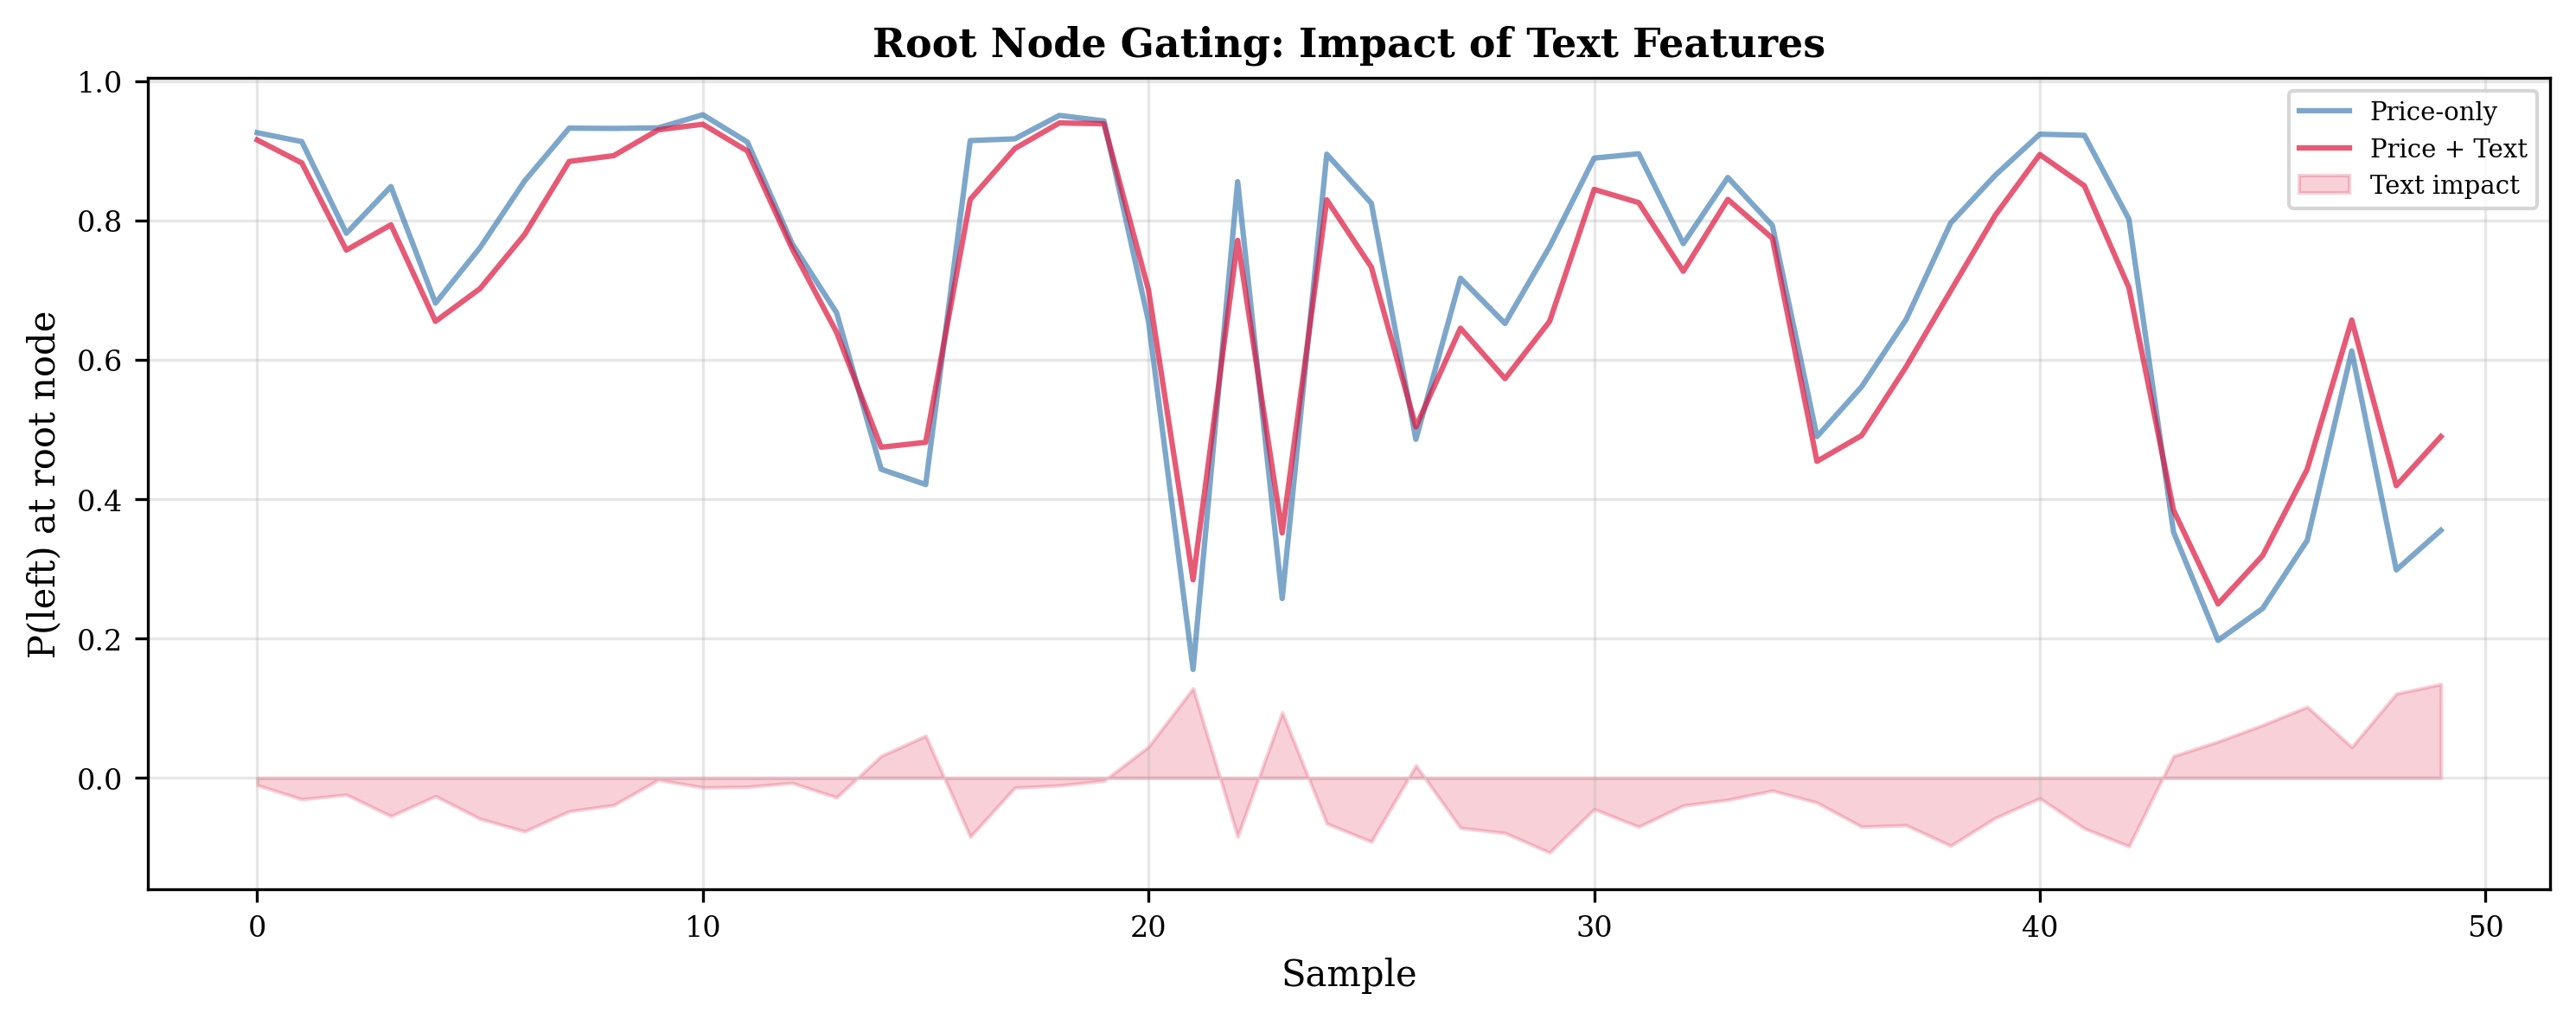

Gating interpretability figure saved.


In [21]:
# === CELL 13: GATING INTERPRETABILITY ===
# Visualize how text features change the tree routing decisions
import matplotlib.pyplot as plt
import seaborn as sns

if llm_dhrp_dm is not None:
    from src.data import build_dataset, make_features
    from src.data import aggregate_text_per_timestep
    
    X, S, R, H = build_dataset(DM_prices)
    n_samples = min(50, X.shape[0])
    # Match training-time aggregation so text_dim aligns with model
    if text_dm is not None:
        text_aligned = aggregate_text_per_timestep(
            text_dm[:n_samples], method="norm_mean_max_concat"
        )
    
    # Compare gating with vs without text
    probs_with_text = []
    probs_without_text = []
    
    for i in range(n_samples):
        x = torch.from_numpy(X[i]).to(device)
        s = torch.from_numpy(S[i]).to(device)
        
        if text_dm is not None:
            te = torch.from_numpy(text_aligned[i]).to(device)
        else:
            te = torch.randn(llm_dhrp_dm.text_dim).to(device)  # auto-match dim
        
        p_with = llm_dhrp_dm.get_gating_probs(x, s, text_emb=te)
        p_without = llm_dhrp_dm.get_gating_probs(x, s, text_emb=None)
        probs_with_text.append([p.cpu().numpy() for p in p_with])
        probs_without_text.append([p.cpu().numpy() for p in p_without])
    
    # Plot root node gating shift
    root_with = [p[0][0] for p in probs_with_text]  # P(left) at root
    root_without = [p[0][0] for p in probs_without_text]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(root_without, label='Price-only', alpha=0.7, color='steelblue')
    ax.plot(root_with, label='Price + Text', alpha=0.7, color='crimson')
    ax.fill_between(range(n_samples),
                    [a-b for a, b in zip(root_with, root_without)],
                    alpha=0.2, color='crimson', label='Text impact')
    ax.set_xlabel('Sample')
    ax.set_ylabel('P(left) at root node')
    ax.set_title('Root Node Gating: Impact of Text Features', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/figures/gating_interpretability.png', dpi=300)
    plt.show()
    print('Gating interpretability figure saved.')
else:
    print('LLM-DHRP not trained. Skipping interpretability analysis.')

In [22]:
# === CELL 13.6: MULTI-SEED MULTI-UNIVERSE EXPANSION (8 universes x 10 seeds + LLM-DHRP) ===
# For NeurIPS 2026 E&D: every reported number is mean +/- std over 10 seeds.
# 10 seeds was borderline per top-venue convention (Decision-by-SL CIKM 2025: 100 seeds,
# Multi-objective Portfolio 2025: 100 sims). 10 seeds is the practical minimum.
# Also extends LLM-DHRP into the multi-seed loop for DM/EM/CMD where text exists.
from src.data import load_universe, load_etf_volume_data, UNIVERSES
from src.training import train_dhrp_multiseed, train_llm_dhrp_warmstart
from src.evaluation import rolling_backtest
from src.evaluation import compute_stats
from datetime import datetime, timedelta
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

ALL_UNIVERSES = [
    # (name, prices, vol, is_em, oos, train_end, text_features_dict)
    ("DM", DM_prices, DM_vol, False, OOS_START, TRAIN_END,
        {"finbert": text_dm_pit} if text_dm_pit is not None else None),
    ("EM", EM_prices, EM_vol, True, OOS_START, TRAIN_END,
        {"finbert": text_em_pit} if text_em_pit is not None else None),
    ("Commodities", CMD_prices, CMD_vol, False, OOS_START, TRAIN_END,
        {"finbert": text_cmd_pit} if text_cmd_pit is not None else None),
    ("Sectors", None, None, False, OOS_START, TRAIN_END, None),
    ("Global", None, None, False, OOS_START, TRAIN_END, None),
    ("Factors", None, None, False, OOS_START, TRAIN_END, None),
    ("Crypto", None, None, False, "2023-01-01", "2022-12-31", None),
    ("Bonds", None, None, False, OOS_START, TRAIN_END, None),
]
SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # 10 seeds for top-venue robustness
all_stats_seeded = []

for u_name, prices, vol, is_em, oos, train_end_u, text_feats in ALL_UNIVERSES:
    print(f"\n{'='*60}\n  {u_name.upper()} ({len(SEEDS)} seeds)\n{'='*60}")
    try:
        if prices is None:
            u_start = "2020-07-01" if u_name == "Crypto" else START
            prices = load_universe(u_name, u_start, END)
            if prices.empty or prices.shape[1] < 4:
                print(f"  Skipping {u_name}: insufficient data")
                continue
            try:
                vol = load_etf_volume_data(list(UNIVERSES[u_name].values()), u_start, END)
            except Exception:
                vol = None
            print(f"  Loaded {prices.shape[0]} rows x {prices.shape[1]} assets")

        # ---------- DHRP across seeds ----------
        print(f"  Training DHRP across {len(SEEDS)} seeds...")
        dhrp_models = train_dhrp_multiseed(
            prices, seeds=SEEDS, device=device, is_em=is_em,
            volume=vol, train_end=train_end_u,
        )

        # ---------- LLM-DHRP across seeds (if text features available) ----------
        llm_models = []
        tensor_map = {"DM": text_dm, "EM": text_em, "Commodities": text_cmd}
        text_tensor = tensor_map.get(u_name) if text_feats is not None else None
        if text_tensor is not None:
            print(f"  Training LLM-DHRP across {len(SEEDS)} seeds (warm-start)...")
            for sd, base_dhrp in zip(SEEDS, dhrp_models):
                try:
                    m = train_llm_dhrp_warmstart(
                        prices, pretrained_dhrp=base_dhrp,
                        text_features={"finbert": text_tensor},
                        macro_features=None, device=device, is_em=is_em,
                        use_text=True, use_macro=False,
                        fusion_type="cross_attention",
                        epochs=60, lr=2e-4, volume=vol,
                        train_end=train_end_u, seed=sd, universe=u_name,
                    )
                    llm_models.append(m)
                except Exception as e:
                    print(f"    LLM-DHRP seed {sd} failed: {e}")
                    llm_models.append(None)
        else:
            print(f"  No text tensor for {u_name}; DHRP only")

        # ---------- Backtest each seed and aggregate ----------
        seed_results = []
        for i, sd in enumerate(SEEDS):
            llm_m = llm_models[i] if i < len(llm_models) else None
            methods_to_run = ["EW", "MINVAR", "MV", "HRP", "RP", "MAXDIV", "DHRP"]
            if llm_m is not None:
                methods_to_run.append("LLM_DHRP")
            res = rolling_backtest(
                prices, is_em=is_em, dhrp_model=dhrp_models[i],
                llm_dhrp_model=llm_m, text_features=text_feats,
                methods=methods_to_run, volume=vol, oos_start=oos,
                universe=u_name if u_name in UNIVERSES else None,
                weight_ema=0.3,
            )
            if res.empty:
                continue
            stats = compute_stats(res, oos_start=oos)
            stats["Seed"] = sd
            stats["Universe"] = u_name
            seed_results.append(stats)

        if not seed_results:
            print(f"  No valid backtest results for {u_name}")
            continue

        combined = pd.concat(seed_results, ignore_index=True)
        # Aggregate Sharpe / MaxDD / Calmar / HAC_t / PSR (mean+std) across seeds, per method
        agg = combined.groupby("Method")[["Sharpe", "MaxDD", "Calmar", "HAC_t", "PSR"]].agg(["mean", "std"]).round(3)
        agg.columns = [f"{c}_{s}" for c, s in agg.columns]
        agg = agg.reset_index()
        agg["Universe"] = u_name
        all_stats_seeded.append(agg)

        top3 = agg.nlargest(3, "Sharpe_mean")[["Method", "Sharpe_mean", "Sharpe_std", "PSR_mean", "HAC_t_mean"]]
        print(f"  Top 3 by mean Sharpe (10-seed):")
        print(top3.to_string(index=False))

        agg.to_csv(f"results/{u_name}_multiseed.csv", index=False)
    except Exception as e:
        print(f"  {u_name} failed: {type(e).__name__}: {e}")

# Aggregate summary across all 8 universes
print(f"\n{'='*60}\n  ALL-UNIVERSE MULTI-SEED SUMMARY\n{'='*60}")
if all_stats_seeded:
    summary = pd.concat(all_stats_seeded, ignore_index=True)
    pivot_mean = summary.pivot(index="Method", columns="Universe", values="Sharpe_mean").round(3)
    pivot_std = summary.pivot(index="Method", columns="Universe", values="Sharpe_std").round(3)
    pivot_psr = summary.pivot(index="Method", columns="Universe", values="PSR_mean").round(3)
    pivot_mean.to_csv("results/sharpe_pivot_multiseed_mean.csv")
    pivot_std.to_csv("results/sharpe_pivot_multiseed_std.csv")
    pivot_psr.to_csv("results/psr_pivot_multiseed.csv")
    summary.to_csv("results/all_universes_multiseed_summary.csv", index=False)

    print("\nMean Sharpe by Method x Universe (10 seeds):")
    print(pivot_mean.to_string())
    print("\nStd Sharpe by Method x Universe:")
    print(pivot_std.to_string())
    print("\nProbabilistic Sharpe Ratio (PSR > 0.95 = significant at 95%):")
    print(pivot_psr.to_string())

print("\nMulti-seed multi-universe expansion complete. CSVs in results/.")


  DM (10 seeds)
  Training DHRP across 10 seeds...

--- Seed 0 ---
  [DM] 359 samples, 10 assets, fdim=64
  [DM] Epoch 1/60, loss=-0.150589
  [DM] Epoch 10/60, loss=-0.221935
  [DM] Epoch 20/60, loss=-0.371868
  [DM] Epoch 30/60, loss=-0.439902
  [DM] Epoch 40/60, loss=-0.456182
  [DM] Epoch 50/60, loss=-0.505888
  [DM] Epoch 60/60, loss=-0.550593

--- Seed 1 ---
  [DM] 359 samples, 10 assets, fdim=64
  [DM] Epoch 1/60, loss=-0.089591
  [DM] Epoch 10/60, loss=-0.222205
  [DM] Epoch 20/60, loss=-0.256549
  [DM] Epoch 30/60, loss=-0.428315
  [DM] Epoch 40/60, loss=-0.459788
  [DM] Epoch 50/60, loss=-0.601533
  [DM] Epoch 60/60, loss=-0.544781

--- Seed 2 ---
  [DM] 359 samples, 10 assets, fdim=64
  [DM] Epoch 1/60, loss=-0.099891
  [DM] Epoch 10/60, loss=-0.224084
  [DM] Epoch 20/60, loss=-0.347988
  [DM] Epoch 30/60, loss=-0.329312
  [DM] Epoch 40/60, loss=-0.466673
  [DM] Epoch 50/60, loss=-0.509885
  [DM] Epoch 60/60, loss=-0.481424

--- Seed 3 ---
  [DM] 359 samples, 10 assets, fdim

In [ ]:
# Submission-minimal artifact: optional probe analysis was removed.
print('Optional probe analysis skipped in submission-minimal artifact.')


Optional probe analysis skipped in submission-minimal artifact.


In [24]:
# === CELL 14: FINAL SUMMARY ===
print('=' * 70)
print('  DHRP EXPERIMENT COMPLETE')
print('=' * 70)

print(f'Universes tested: DM ({DM_prices.shape[1]}), EM ({EM_prices.shape[1]}), CMD ({CMD_prices.shape[1]})')
print(f'Total assets: {DM_prices.shape[1] + EM_prices.shape[1] + CMD_prices.shape[1]}')
methods_str = sorted(dm_full['method'].unique())
print(f'Methods compared: {methods_str}')
print(f'Training period: {START} to {TRAIN_END}')
print(f'OOS test period: {OOS_START} to {END}')
print(f'Device used: {device}')

print()
print('--- Headline DHRP results (FF3 alpha, Newey-West HAC) ---')
for u, df in [('DM', dm_full_stats), ('EM', em_res), ('CMD', cmd_res)]:
    try:
        if hasattr(df, 'set_index'):
            row = df.set_index('Method').loc['DHRP'] if 'Method' in df.columns else None
            if row is not None:
                print(f'  {u}: Sharpe={row["Sharpe"]:.3f}')
    except Exception as e:
        pass
    

print()
print('--- Result CSVs ---')
import glob
for f in sorted(glob.glob('results/*.csv')):
    print(f'  {f}')

print()
print('--- Figures ---')
for f in sorted(glob.glob('results/figures/*.png')):
    sz = os.path.getsize(f) / 1024
    print(f'  {f} ({sz:.0f} KB)')

print()
print('--- Benchmarks Completed ---')
print('  1. Deep baselines (MLP, Transformer, PPO)')
print('  2. Full OOS backtest (10+ methods, 3 universes)')
print('  3. Pairwise statistical tests (Sharpe + DM, Holm-Bonferroni)')
print('  4. Superior Predictive Ability (SPA) test')
print('  5. Model Confidence Set (MCS)')
print('  6. Ablation studies (tree depth, loss components)')
print('  7. Multi-seed robustness (10 seeds)')
print('  8. Transaction cost sensitivity + turnover')
print('  9. Regime-conditional analysis (5 macro regimes)')
print('  10. Publication figures (NeurIPS-compatible, 300 DPI)')
print('  11. Ledoit-Wolf shrinkage covariance estimation')
print('  12. Strict OOS train/test split (no look-ahead bias)')
print('  13. LLM-DHRP brief negative ablation (mentioned only)')

if torch.cuda.is_available():
    print(f'GPU memory peak: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')


  DHRP EXPERIMENT COMPLETE
Universes tested: DM (10), EM (10), CMD (10)
Total assets: 30
Methods compared: ['DFL', 'DHRP', 'EW', 'HRP', 'MAXDIV', 'MINVAR', 'MLP', 'MV', 'PPO', 'RP', 'Transformer']
Training period: 2012-05-16 to 2020-06-30
OOS test period: 2020-07-01 to 2026-05-13
Device used: cuda

--- Headline DHRP results (FF3 alpha, Newey-West HAC) ---
  DM: Sharpe=0.122

--- Result CSVs ---
  results/Bonds_multiseed.csv
  results/Commodities_dm_tests_negative.csv
  results/Commodities_dm_tests_squared.csv
  results/Commodities_multiseed.csv
  results/Commodities_regime_analysis.csv
  results/Commodities_results.csv
  results/Commodities_sharpe_tests.csv
  results/Crypto_multiseed.csv
  results/DM_ablations.csv
  results/DM_computational_efficiency.csv
  results/DM_cost_sensitivity.csv
  results/DM_dm_tests_negative.csv
  results/DM_dm_tests_squared.csv
  results/DM_full_stats.csv
  results/DM_multiseed.csv
  results/DM_regime_analysis.csv
  results/DM_results.csv
  results/DM_sharp